In [2]:
# --- 1. Imports, Configuration & Paths ---
import os
import re
import yaml
import shutil
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.colors import ListedColormap
import random
import multiprocessing
from concurrent.futures import ThreadPoolExecutor

# --- IEEE / Paper Plotting Style ---
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['figure.dpi'] = 300 

# --- Paths ---
NOXIM_BIN_DIR = Path("../../bin").resolve()
NOXIM_EXEC = "./noxim"
CONFIG_DIR = Path("../../configs/custom_config").resolve()
TEMP_CONFIG_DIR = Path("temp_configs").resolve()
TEMP_CONFIG_DIR.mkdir(exist_ok=True)
PLOTS_DIR = Path("plots").resolve()
PLOTS_DIR.mkdir(exist_ok=True)

# --- Parallelization ---
# Use (CPU Cores - 1) to keep the system responsive, or specific number
MAX_WORKERS = max(1, multiprocessing.cpu_count() - 1)
print(f"Parallel execution enabled with {MAX_WORKERS} workers.")

NUM_SEEDS = 10  # Set to 1 as requested, can increase for more statistical robustness
SEEDS = [random.randint(1, 10000) for _ in range(NUM_SEEDS)]

# --- Protocols & Configs ---
PROTOCOLS = {
    "Token Passing": CONFIG_DIR / "token_packet_soteriou_traffic.yaml",
    "Fuzzy Token": CONFIG_DIR / "fuzzy_token_soteriou_traffic.yaml",
    "FP-Jump": CONFIG_DIR / "fuzzy_swj_soteriou_traffic.yaml",
    # "FP-Jump + RG": CONFIG_DIR / "fuzzy_raj_soteriou_traffic.yaml"
}

# --- Parsing Patterns ---
METRIC_PATTERNS = {
    "network_throughput": re.compile(r"Network throughput \(flits/cycle\):\s*([0-9.]+)"),
    "global_average_delay": re.compile(r"Global average delay \(cycles\):\s*([0-9.]+)"),
    "total_energy": re.compile(r"Total energy \(J\):\s*([0-9.eE+-]+)"),
    "dynamic_energy": re.compile(r"Dynamic energy \(J\):\s*([0-9.eE+-]+)"),
    "static_energy": re.compile(r"Static energy \(J\):\s*([0-9.eE+-]+)"),
    "received_packets": re.compile(r"Total received packets:\s*([0-9]+)"),
    "received_flits": re.compile(r"Total received flits:\s*([0-9]+)"),
    "simulation_cycles": re.compile(r"Noxim simulation completed\.\s*\(([0-9]+)\s+cycles executed\)"),
}

Parallel execution enabled with 7 workers.


In [3]:
# --- 2. Helper Functions (Simulation & Plotting) ---

def parse_noxim_output(output):
    """Parses stdout from noxim to extract defined metrics."""
    metrics = {}
    for key, pattern in METRIC_PATTERNS.items():
        match = pattern.search(output)
        if match:
            metrics[key] = float(match.group(1))
        else:
            metrics[key] = float("nan")
    return metrics

def run_noxim(config_path, pir_val=None, seed=42, overrides=None):
    """
    Runs noxim with the given config and arguments.
    """
    cmd = [NOXIM_EXEC, "-config", str(config_path), "-seed", str(seed)]
    
    if pir_val is not None:
        cmd.extend(["-pir", str(pir_val), "poisson"])
    
    if overrides:
        for k, v in overrides.items():
            cmd.append(k)
            if isinstance(v, list):
                cmd.extend([str(i) for i in v])
            else:
                cmd.append(str(v))
                
    try:
        proc = subprocess.run(
            cmd, 
            cwd=str(NOXIM_BIN_DIR), 
            capture_output=True, 
            text=True, 
            timeout=120
        )
        if proc.returncode != 0:
            print(f"Error running noxim: {proc.stderr}")
            return {}
        return parse_noxim_output(proc.stdout)
    except Exception as e:
        print(f"Exception: {e}")
        return {}

def run_with_temp_config(base_cfg, unique_filename, seed, pir_val):
    """
    Helper to create a temp config, run noxim, and cleanup.
    Useful for parallel execution where each task needs a unique config file.
    """
    temp_path = TEMP_CONFIG_DIR / unique_filename
    with open(temp_path, 'w') as f:
        yaml.dump(base_cfg, f)
        
    try:
        return run_noxim(temp_path, pir_val=pir_val, seed=seed)
    finally:
        if temp_path.exists():
            try:
                temp_path.unlink()
            except:
                pass

def calculate_gmean(values):
    """Calculates Geometric Mean, handling non-positive values safely."""
    if not values: return float("nan")
    a = np.array(values)
    a = a[a > 0] # Filter non-positive for log
    if len(a) == 0: return 0.0
    return np.exp(np.mean(np.log(a)))

def aggregate_runs(run_list):
    """
    Aggregates a list of metric dictionaries using Geometric Mean for all numerical fields.
    """
    if not run_list: return {}
    
    agg = {}
    keys = run_list[0].keys()
    
    for k in keys:
        values = [r.get(k, float('nan')) for r in run_list]
        agg[k] = calculate_gmean(values)
        
    return agg

def save_figure_png_eps(filename, dpi=300):
    """Save current matplotlib figure as both PNG and EPS in the plots directory."""
    png_path = PLOTS_DIR / filename
    eps_path = png_path.with_suffix(".eps")
    plt.savefig(png_path, dpi=dpi, bbox_inches='tight')
    plt.savefig(eps_path, format='eps', bbox_inches='tight')
    print(f"Saved: {png_path}")
    print(f"Saved: {eps_path}")

def plot_comparisons(
    df, x_col, y_col, title, ylabel, log_y=False, filename=None, legend=True,
    xlabel_override=None, xlim_left=None, xlim_right=None
    ):
    """
    Generic plotting function for protocol comparisons.
    """
    plt.figure(figsize=(8, 6))
    
    style_map = {
        "Token Passing":      {"marker": "x", "color": "#333333", "linestyle": "--", "label": "Token Passing (Baseline)"},
        "Fuzzy Token":        {"marker": "o", "color": "#1f77b4", "linestyle": "-",  "label": "Fuzzy Token"},
        "FP-Jump":            {"marker": "D", "color": "#2ca02c", "linestyle": "-",  "label": "FP-Jump (Proposed)"},
        "FP-Jump + RG":       {"marker": "^", "color": "#e2de10", "linestyle": "-.", "label": "FP-Jump + RG (Ideal)"}
    }

    for proto in df["protocol"].unique():
        if proto not in style_map: continue
        subset = df[df["protocol"] == proto].sort_values(x_col)
        
        s = style_map[proto]
        plt.plot(subset[x_col], subset[y_col], 
                 label=s["label"], 
                 marker=s["marker"], 
                 color=s["color"], 
                 linestyle=s["linestyle"],
                 linewidth=2 if proto == "FP-Jump" else 1.5, 
                 markersize=8 if proto == "FP-Jump" else 7,
                 markeredgewidth=1.5,
                 alpha=0.9)
    
    if xlabel_override:
        plt.xlabel(xlabel_override)
    elif (x_col == "pir"):
        plt.xlabel("Packet Injection Rate (packets/cycle/node)")
    elif (x_col == "hurst"):
        plt.xlabel("Hurst Exponent (H)")
    else:
        plt.xlabel(x_col.replace("_", " ").title())
        
    plt.ylabel(ylabel)
    # plt.title(title, pad=15)
    
    if log_y: 
        plt.yscale("log")
    
    if xlim_left is not None or xlim_right is not None:
        plt.xlim(left=xlim_left, right=xlim_right)
        
    plt.grid(True, which="both", linestyle=':', linewidth=0.5, alpha=0.6, color='gray')
    if legend:
        plt.legend(frameon=True, fancybox=False, edgecolor='black', loc='best')
    plt.tight_layout()
    
    if filename:
        save_figure_png_eps(filename, dpi=300)
    plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: /Users/nishkarsh/Programming/noxim/results/paper_results/plots/fig_modeled_energy_random64.png
Saved: /Users/nishkarsh/Programming/noxim/results/paper_results/plots/fig_modeled_energy_random64.eps
Saved modeled CSV: /Users/nishkarsh/Programming/noxim/results/paper_results/plots/modeled_energy_random64.csv
Saved modeled plot: /Users/nishkarsh/Programming/noxim/results/paper_results/plots/fig_modeled_energy_random64.png


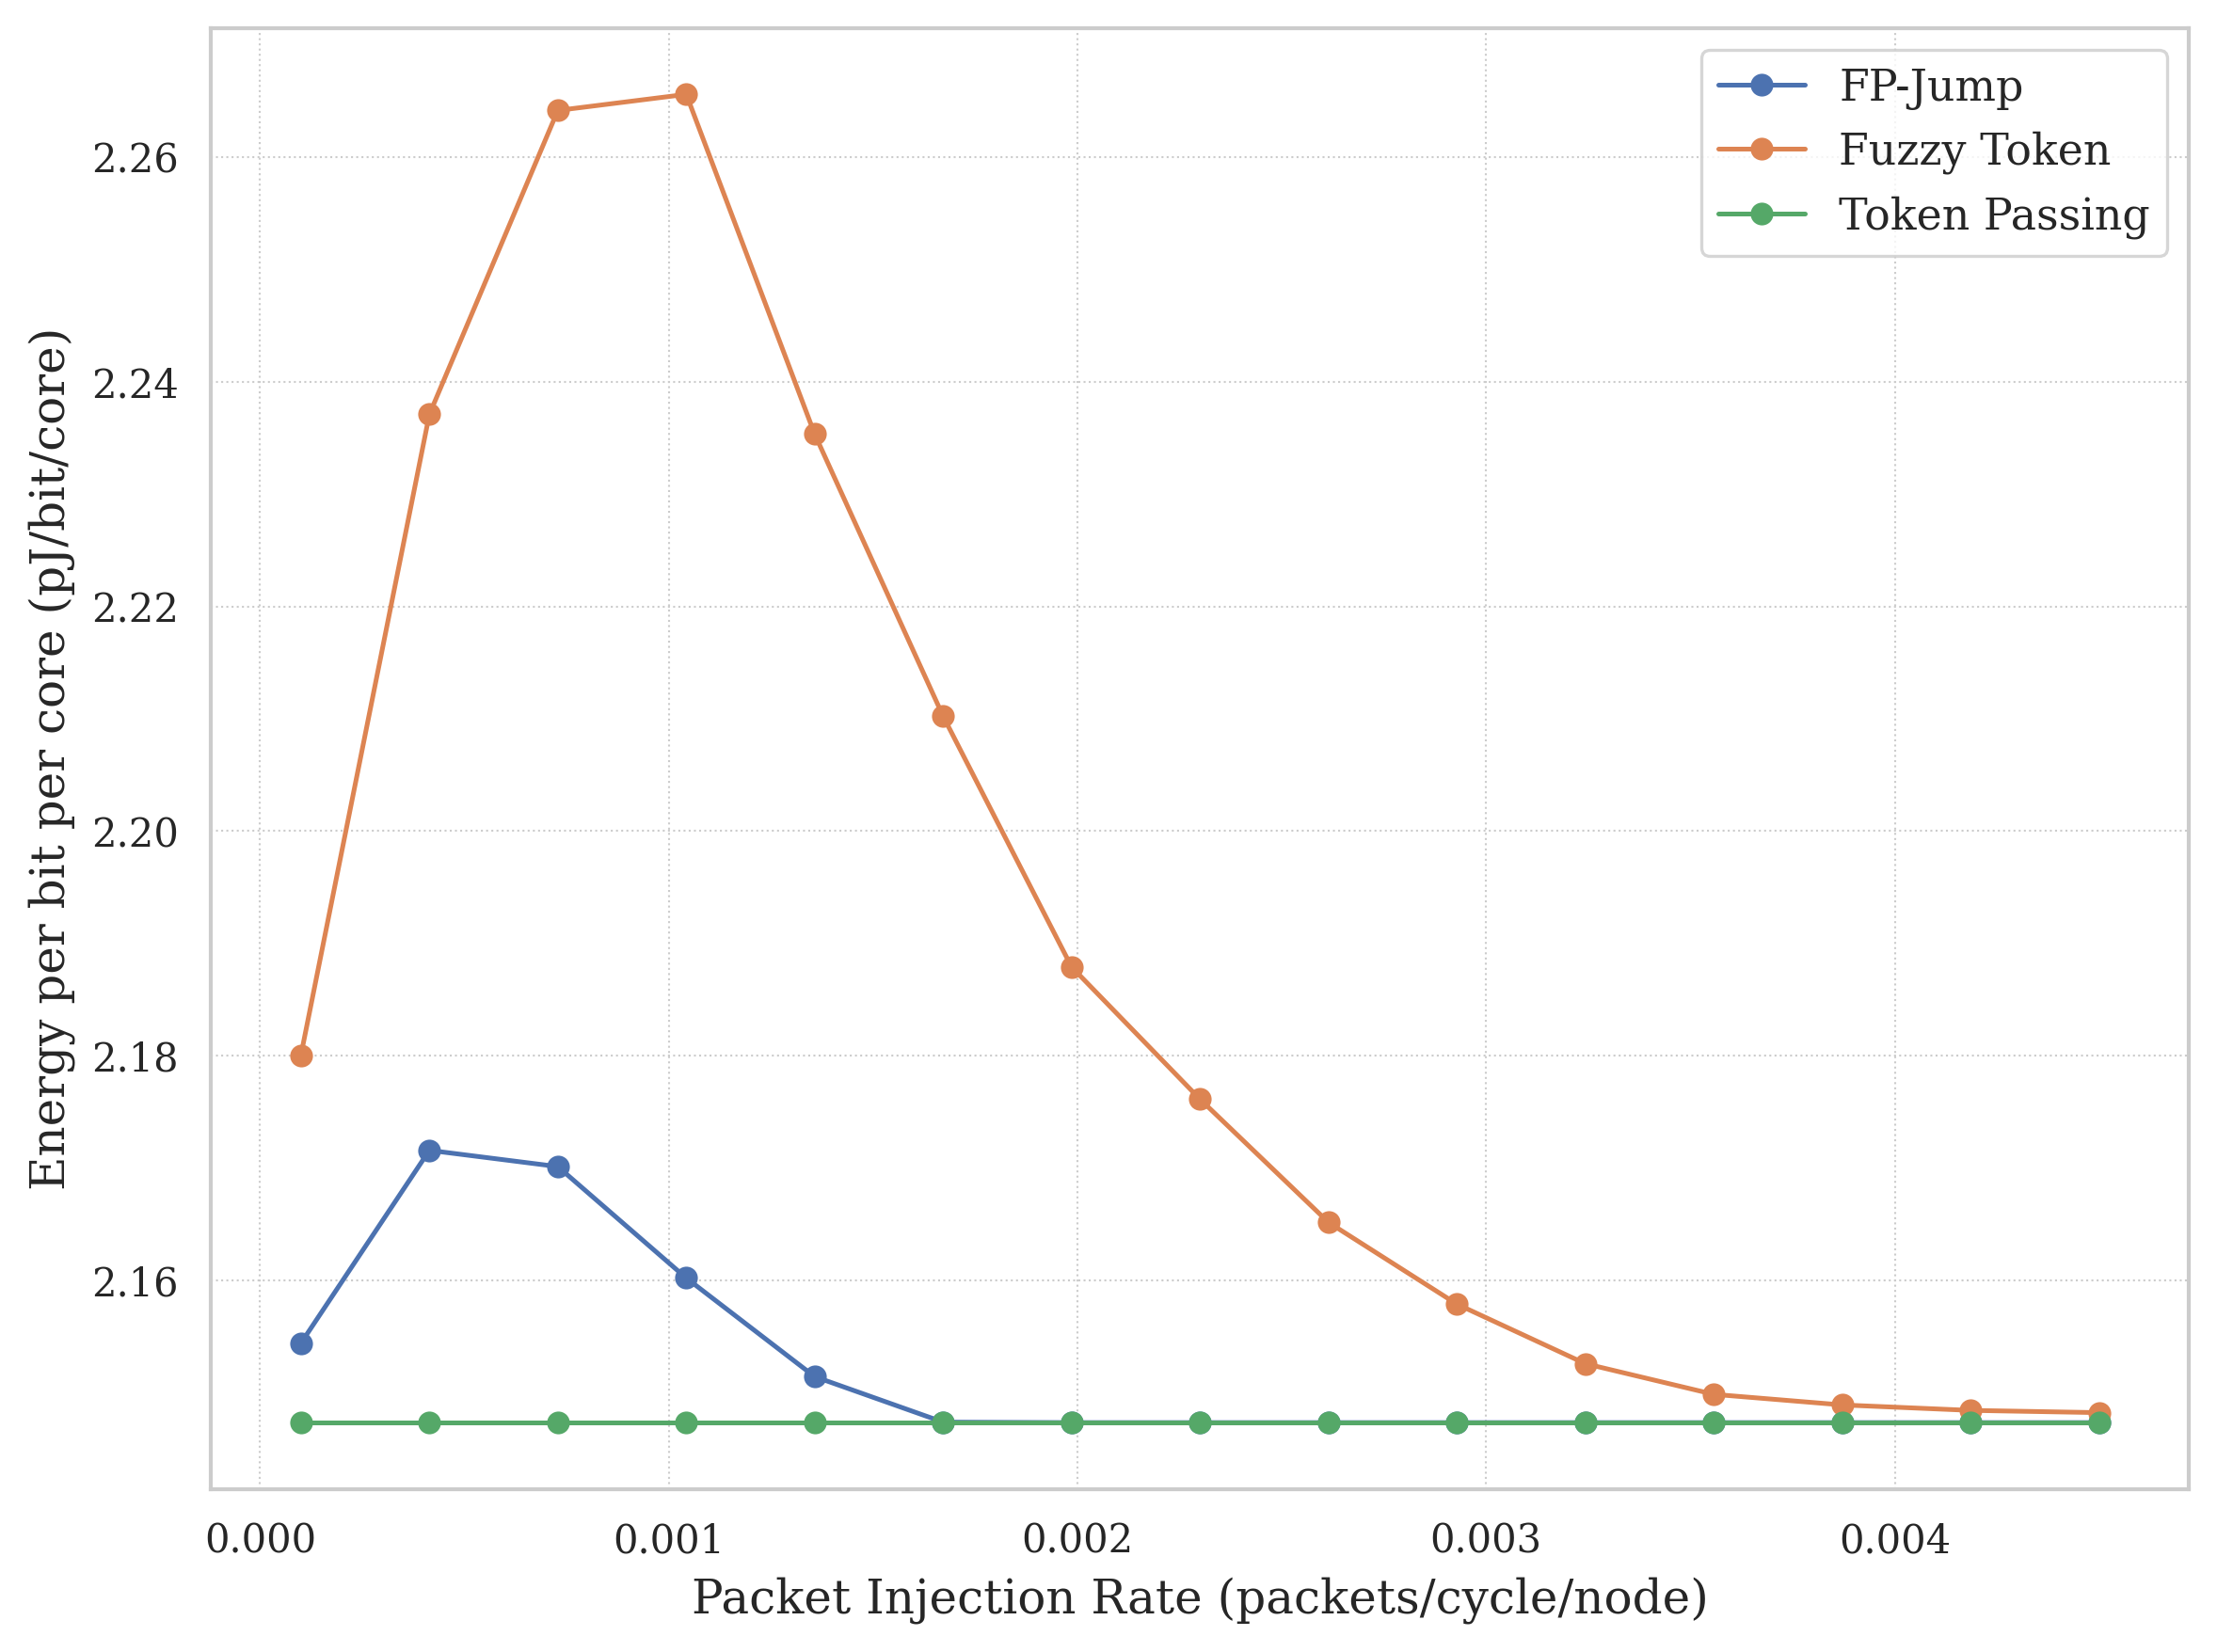

In [5]:
# --- New: Modeled Energy vs Load (random traffic, 64 hubs, 15-point PIR, 10 seeds) ---

MODELED_PROTOCOLS = {
    "Token Passing": CONFIG_DIR / "token_packet_8x8_64hubs.yaml",
    "Fuzzy Token": CONFIG_DIR / "fuzzy_token_8x8_64hubs.yaml",
    "FP-Jump": CONFIG_DIR / "fuzzy_raj_8x8_64hubs.yaml",
}

PIR_LIST_MODELED = [round(x, 7) for x in np.linspace(0.0001, 0.0045, 15)]
SEEDS_MODELED = list(range(1, 11))

COLLISION_PATTERN = re.compile(r"Number of collisions detected:\s+(\d+)")
SUCCESS_PATTERN = re.compile(r"Total Successes:\s+(\d+)")


def load_cfg_meta(config_path):
    with open(config_path, "r") as f:
        cfg = yaml.safe_load(f)
    flit_size = int(cfg.get("flit_size", 16))
    mesh_x = int(cfg.get("mesh_dim_x", 1))
    mesh_y = int(cfg.get("mesh_dim_y", 1))
    pkt_min = int(cfg.get("min_packet_size", 1))
    pkt_max = int(cfg.get("max_packet_size", pkt_min))
    pkt_size_flits = (pkt_min + pkt_max) / 2.0
    preamble = 0
    try:
        preamble = int(cfg["RadioChannels"]["defaults"].get("fuzzy_token", {}).get("preamble_cycles", 0))
    except Exception:
        preamble = 0
    return {
        "flit_size": flit_size,
        "mesh_x": mesh_x,
        "mesh_y": mesh_y,
        "pkt_size_flits": pkt_size_flits,
        "preamble_cycles": preamble,
    }


def parse_collisions(stdout):
    coll = COLLISION_PATTERN.search(stdout)
    succ = SUCCESS_PATTERN.search(stdout)
    collisions = int(coll.group(1)) if coll else 0
    successes = int(succ.group(1)) if succ else 0
    return collisions, successes


def run_modeled_case(protocol, config_path, pir, seed, cfg_meta):
    cmd = [
        NOXIM_EXEC,
        "-config",
        str(config_path),
        "-pir",
        str(pir),
        "poisson",
        "-traffic",
        "random",
        "-seed",
        str(seed),
        "-power",
        "power.yaml",
    ]
    proc = subprocess.run(cmd, cwd=str(NOXIM_BIN_DIR), capture_output=True, text=True, timeout=180)
    if proc.returncode != 0:
        raise RuntimeError(f"Run failed ({protocol}, pir={pir}, seed={seed}): {proc.stderr}")

    metrics = parse_noxim_output(proc.stdout)
    collisions, successes = parse_collisions(proc.stdout)

    flits = metrics.get("received_flits", 0.0)
    dyn_energy = metrics.get("dynamic_energy", 0.0)
    bits = flits * cfg_meta["flit_size"]
    cores = cfg_meta["mesh_x"] * cfg_meta["mesh_y"]
    denom = bits * cores
    dyn_per_bit_core = (dyn_energy / denom) if denom > 0 else float("nan")
    n_re = (collisions / successes) if successes > 0 else 0.0

    return {
        "protocol": protocol,
        "pir": pir,
        "seed": seed,
        "dynamic_energy_per_bit_core": dyn_per_bit_core,
        "n_re": n_re,
        "collisions": collisions,
        "successes": successes,
        "flits": flits,
        "dyn_energy": dyn_energy,
        "cores": cores,
        "preamble_cycles": cfg_meta["preamble_cycles"],
        "pkt_size_flits": cfg_meta["pkt_size_flits"],
    }


def aggregate_modeled(rows):
    agg = {}
    if not rows:
        return agg
    agg["protocol"] = rows[0]["protocol"]
    agg["pir"] = rows[0]["pir"]
    positive_dyn = [r["dynamic_energy_per_bit_core"] for r in rows if r["dynamic_energy_per_bit_core"] > 0]
    agg["gmean_dynamic_energy_per_bit_core"] = calculate_gmean(positive_dyn) if positive_dyn else float("nan")
    agg["mean_n_re"] = float(np.mean([r["n_re"] for r in rows])) if rows else float("nan")
    agg["preamble_cycles"] = rows[0]["preamble_cycles"]
    agg["pkt_size_flits"] = rows[0]["pkt_size_flits"]
    agg["load_pkts_per_cycle_per_chip"] = rows[0]["pir"] * rows[0]["cores"]
    return agg


# Run sweep (may take a couple of minutes)
modeled_rows = []
for proto, cfg_path in MODELED_PROTOCOLS.items():
    cfg_meta = load_cfg_meta(cfg_path)
    for pir in PIR_LIST_MODELED:
        seed_results = []
        futures = []
        with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
            for sd in SEEDS_MODELED:
                futures.append(executor.submit(run_modeled_case, proto, cfg_path, pir, sd, cfg_meta))
            for f in futures:
                seed_results.append(f.result())
        modeled_rows.append(aggregate_modeled(seed_results))

modeled_df = pd.DataFrame(modeled_rows)

# Anchor E_OK to Token Passing at lowest PIR (dynamic energy per bit per core)
base_token = modeled_df[(modeled_df.protocol == "Token Passing") & (modeled_df.pir == modeled_df.pir.min())]
if not base_token.empty:
    e_ok = base_token.iloc[0]["gmean_dynamic_energy_per_bit_core"]
else:
    e_ok = float("nan")

modeled_df["modeled_energy_per_bit_core"] = e_ok * (
    1.0 + (modeled_df["preamble_cycles"] / modeled_df["pkt_size_flits"]) * modeled_df["mean_n_re"]
)

# Save and plot
modeled_csv = PLOTS_DIR / "modeled_energy_random64.csv"
modeled_df.to_csv(modeled_csv, index=False)

plt.figure(figsize=(8, 6))
for proto, grp in modeled_df.groupby("protocol"):
    plt.plot(
        grp["pir"],
        grp["modeled_energy_per_bit_core"] * 1.0e12,  # pJ/bit/core
        marker="o",
        label=f"{proto}"
    )
plt.xlabel("Packet Injection Rate (packets/cycle/node)")
plt.ylabel("Energy per bit per core (pJ/bit/core)")
plt.grid(True, which="both", linestyle=":", linewidth=0.5)
plt.legend()
plt.tight_layout()
modeled_plot_path = PLOTS_DIR / "fig_modeled_energy_random64.png"
save_figure_png_eps(modeled_plot_path.name, dpi=300)
print(f"Saved modeled CSV: {modeled_csv}")
print(f"Saved modeled plot: {modeled_plot_path}")


In [7]:
# --- 3. Simulation: PIR Sweep (Multi-Seed) ---
# Generates data for Figures 1, 2, 6, 7

# Configuration
PIR_LIST = [round(x, 4) for x in np.linspace(0.0005, 0.04, 20)]

results_pir_multiseed = []

print(f"Running PIR Sweep ({NUM_SEEDS} seeds) with parallel execution...")

# Create executor once for the entire sweep to minimize overhead
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    for protocol_name, config_path in PROTOCOLS.items():
        print(f"  Protocol: {protocol_name}")
        
        # Extract flit size for energy calc
        try:
            with open(config_path, 'r') as f:
                p_cfg = yaml.safe_load(f)
                p_flit_size = int(p_cfg.get("flit_size", 32))
        except Exception as e:
            print(f"Warning: Could not read flit_size from {config_path}, defaulting to 32. Error: {e}")
            p_flit_size = 32

        for pir in PIR_LIST:
            
            # PARALLEL: Submit all seeds for this (protocol, pir) configuration
            # map returns an iterator that yields results in order as they complete (or map order)
            # executor.map is strictly ordered, which is fine here.
            # Using list(executor.map(...)) waits for all to complete.
            
            # Lambda isn't pickleable for ProcessPool, but fine for ThreadPool. 
            # However, safer to use list comprehension with submit for clarity/error handling.
            futures = [executor.submit(run_noxim, config_path, pir_val=pir, seed=s) for s in SEEDS]
            
            runs = []
            for f in futures:
                m = f.result()
                
                # Pre-calculate Energy per Packet per run
                pkts = m.get("received_packets", 0)
                energy = m.get("total_energy", 0)
                dyn_energy = m.get("dynamic_energy", 0)
                stat_energy = m.get("static_energy", 0)
                flits = m.get("received_flits", 0)
                
                if pkts and pkts > 0:
                    m["energy_per_pkt"] = energy / pkts
                else:
                    m["energy_per_pkt"] = float("nan")
                    
                # Calculate Energy per Bit (pJ)
                if flits and flits > 0:
                    # Energy (J) / (Flits * Bits/Flit) * 1e12 pJ/J
                    total_bits = flits * p_flit_size
                    m["energy_per_bit_pJ"] = (energy / total_bits) * 1.0e12
                    m["dynamic_per_bit_pJ"] = (dyn_energy / total_bits) * 1.0e12
                    m["static_per_bit_pJ"] = (stat_energy / total_bits) * 1.0e12
                else:
                    m["energy_per_bit_pJ"] = float("nan")
                    m["dynamic_per_bit_pJ"] = float("nan")
                    m["static_per_bit_pJ"] = float("nan")
                
                runs.append(m)
                
            # Aggregate using GMean
            agg = aggregate_runs(runs)
            
            entry = {
                "protocol": protocol_name,
                "pir": pir,
                "avg_delay": agg.get("global_average_delay"),
                "throughput": agg.get("network_throughput"), 
                "energy_J": agg.get("total_energy"),
                "energy_per_pkt": agg.get("energy_per_pkt"),
                "energy_per_bit_pJ": agg.get("energy_per_bit_pJ"),
                "dynamic_per_bit_pJ": agg.get("dynamic_per_bit_pJ"),
                "static_per_bit_pJ": agg.get("static_per_bit_pJ"),
                "pkts": agg.get("received_packets")
            }
            results_pir_multiseed.append(entry)

df_pir = pd.DataFrame(results_pir_multiseed)
print("PIR Sweep Simulation Complete.")
# Save CSV for backup
df_pir.to_csv(PLOTS_DIR / "pir_sweep_results.csv", index=False)

Running PIR Sweep (10 seeds) with parallel execution...
  Protocol: Token Passing
  Protocol: Fuzzy Token
  Protocol: FP-Jump
PIR Sweep Simulation Complete.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: /Users/nishkarsh/Programming/noxim/results/paper_results/plots/fig1_throughput.png
Saved: /Users/nishkarsh/Programming/noxim/results/paper_results/plots/fig1_throughput.eps


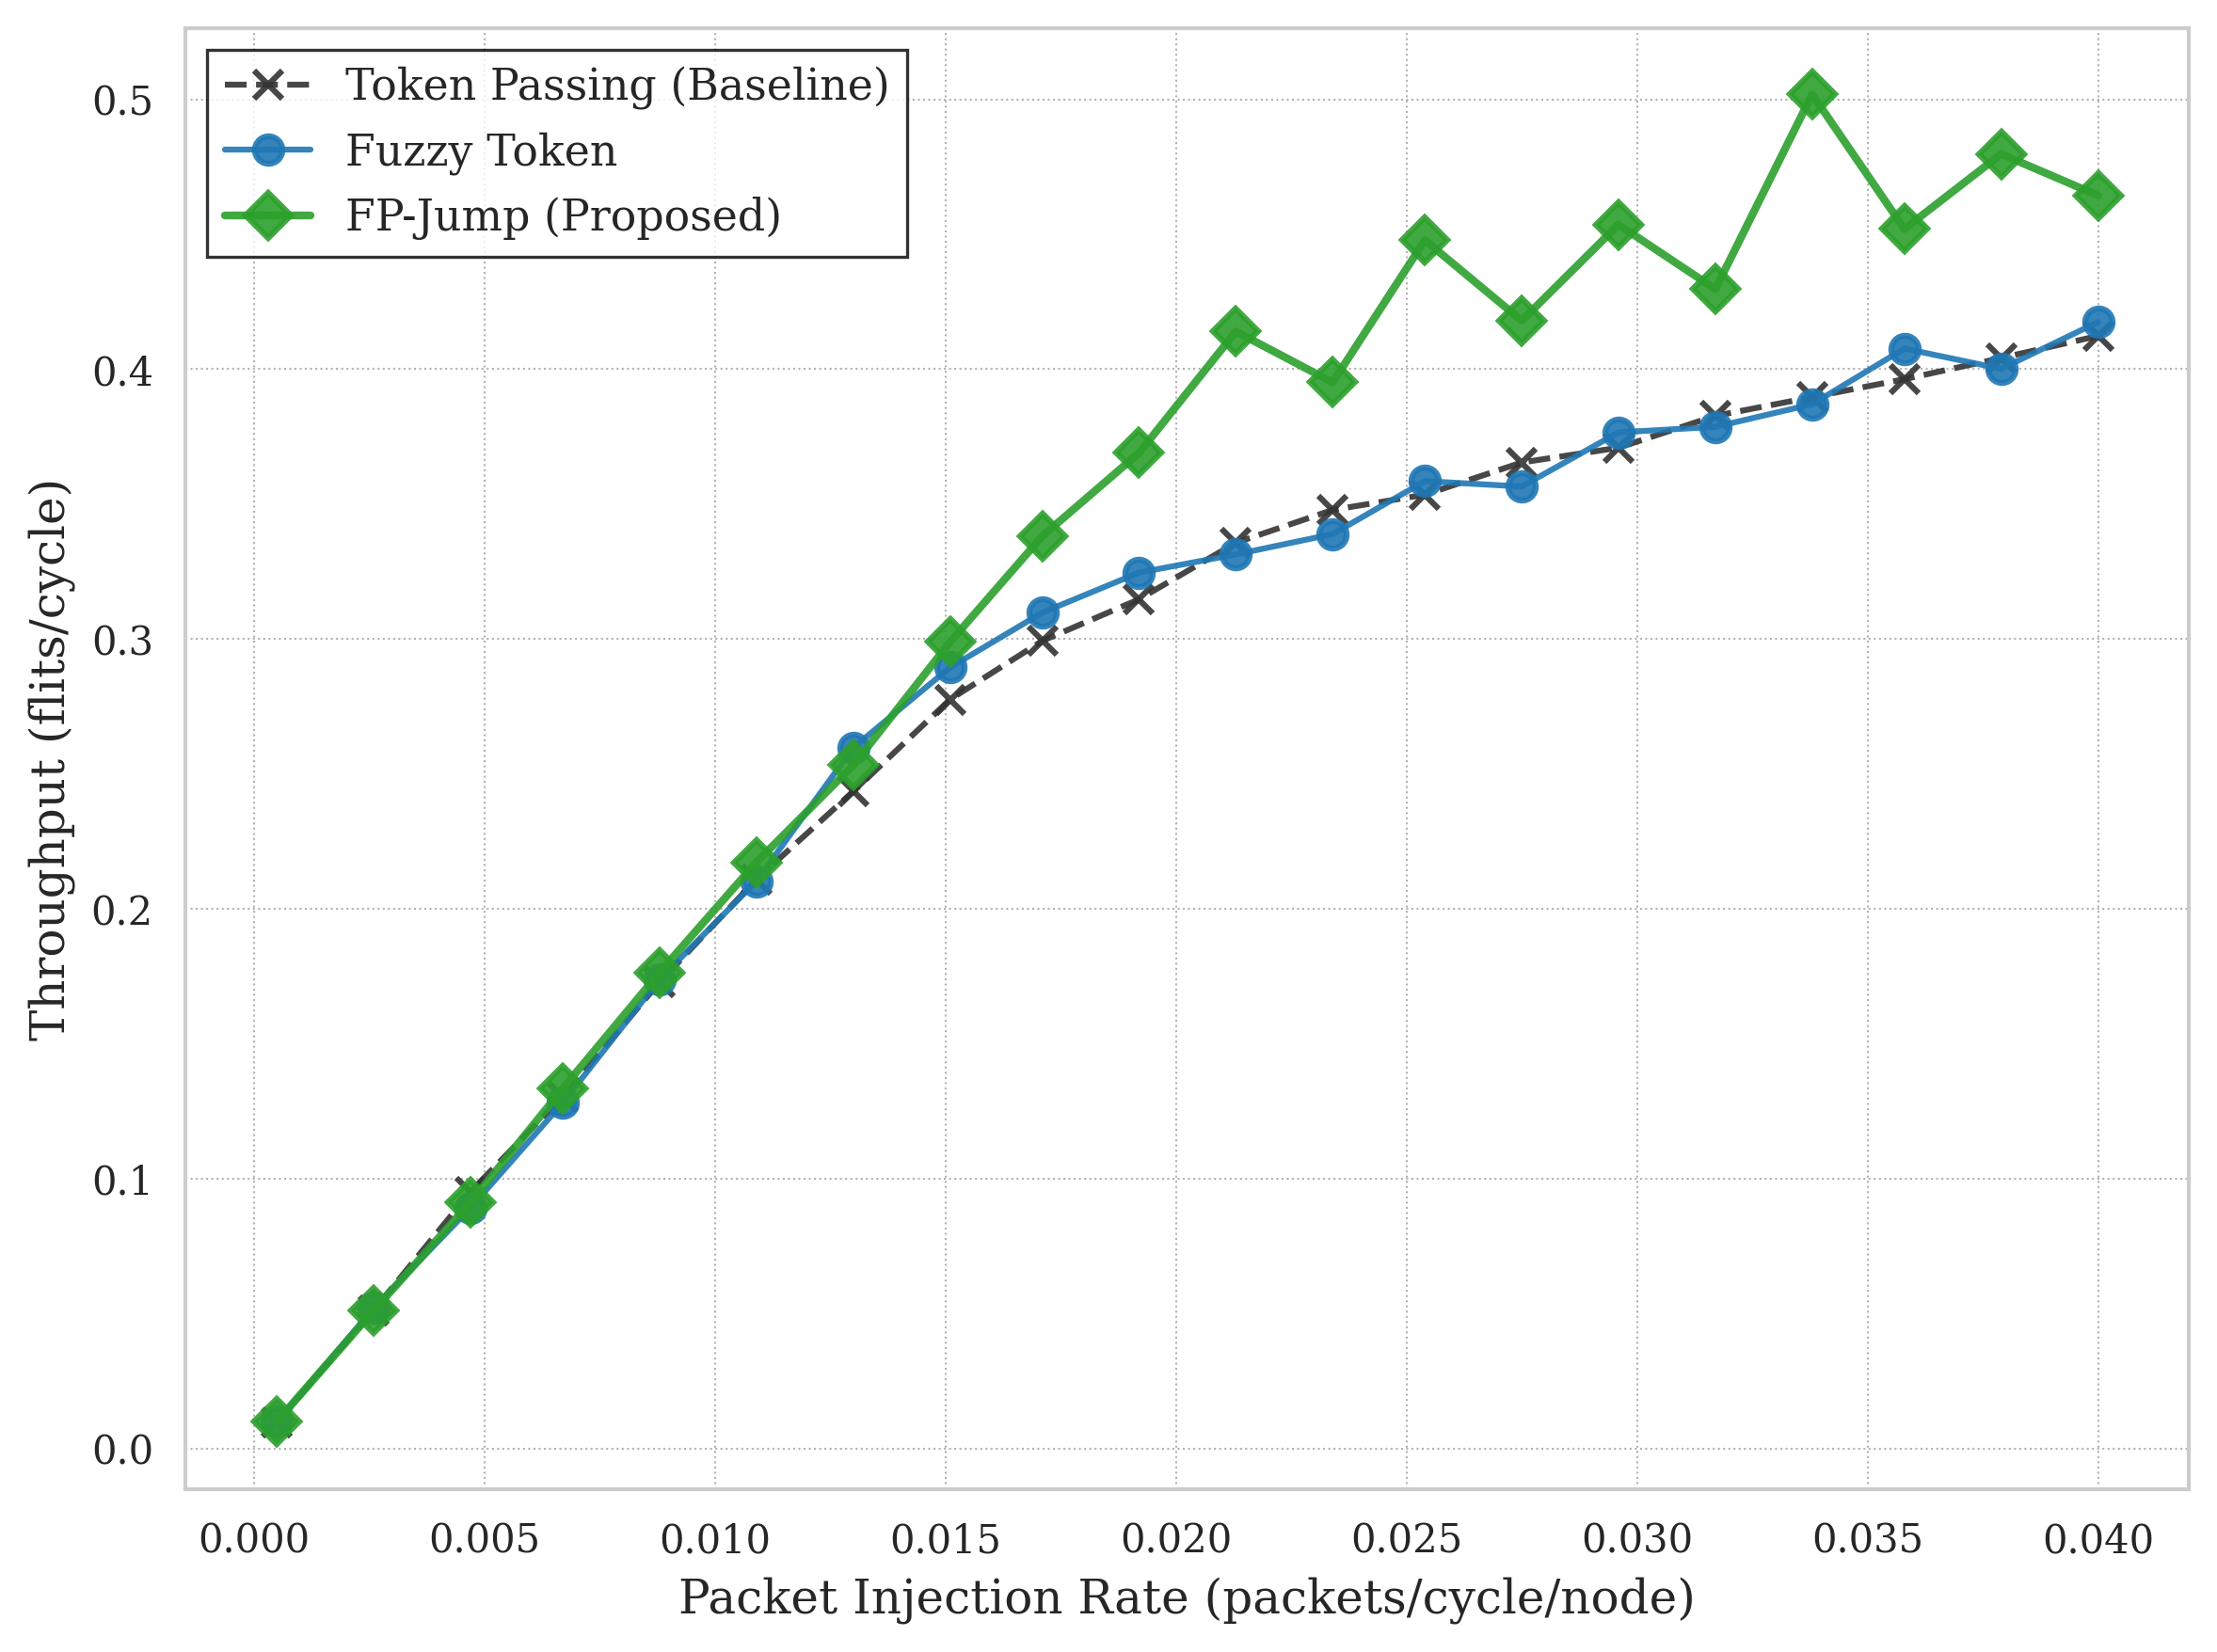

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: /Users/nishkarsh/Programming/noxim/results/paper_results/plots/fig2_latency.png
Saved: /Users/nishkarsh/Programming/noxim/results/paper_results/plots/fig2_latency.eps


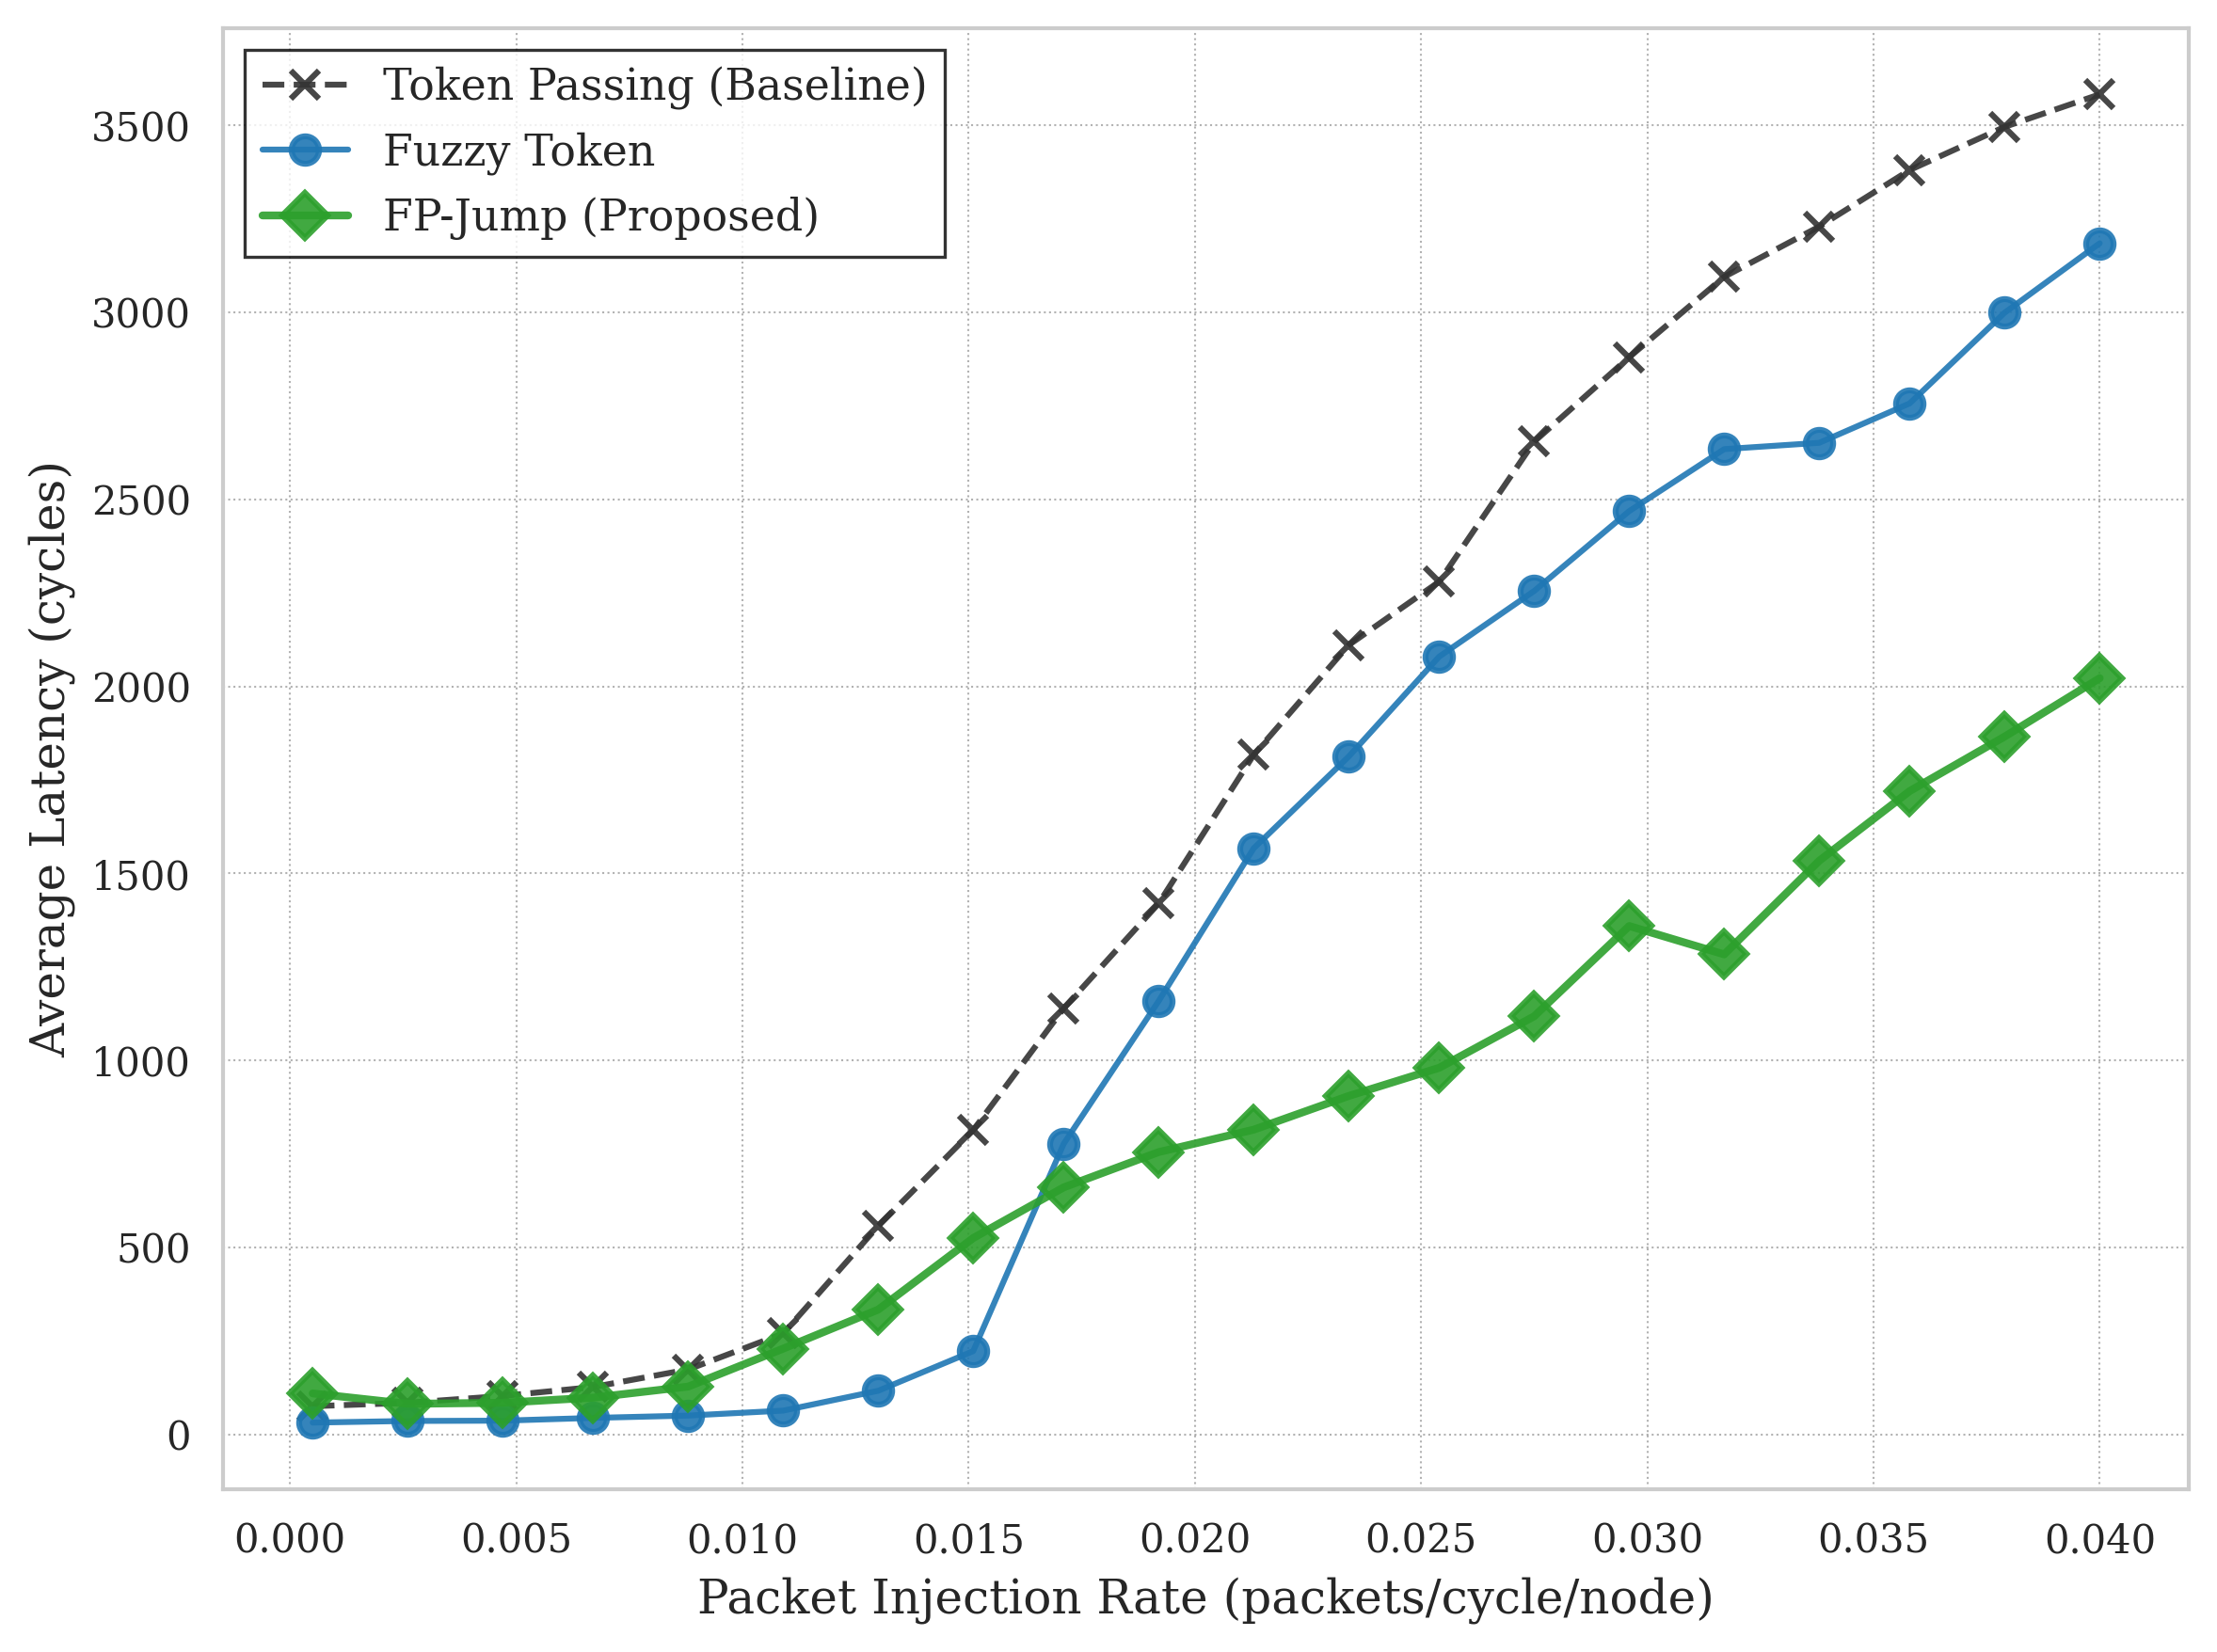

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: /Users/nishkarsh/Programming/noxim/results/paper_results/plots/fig7_rg.png
Saved: /Users/nishkarsh/Programming/noxim/results/paper_results/plots/fig7_rg.eps


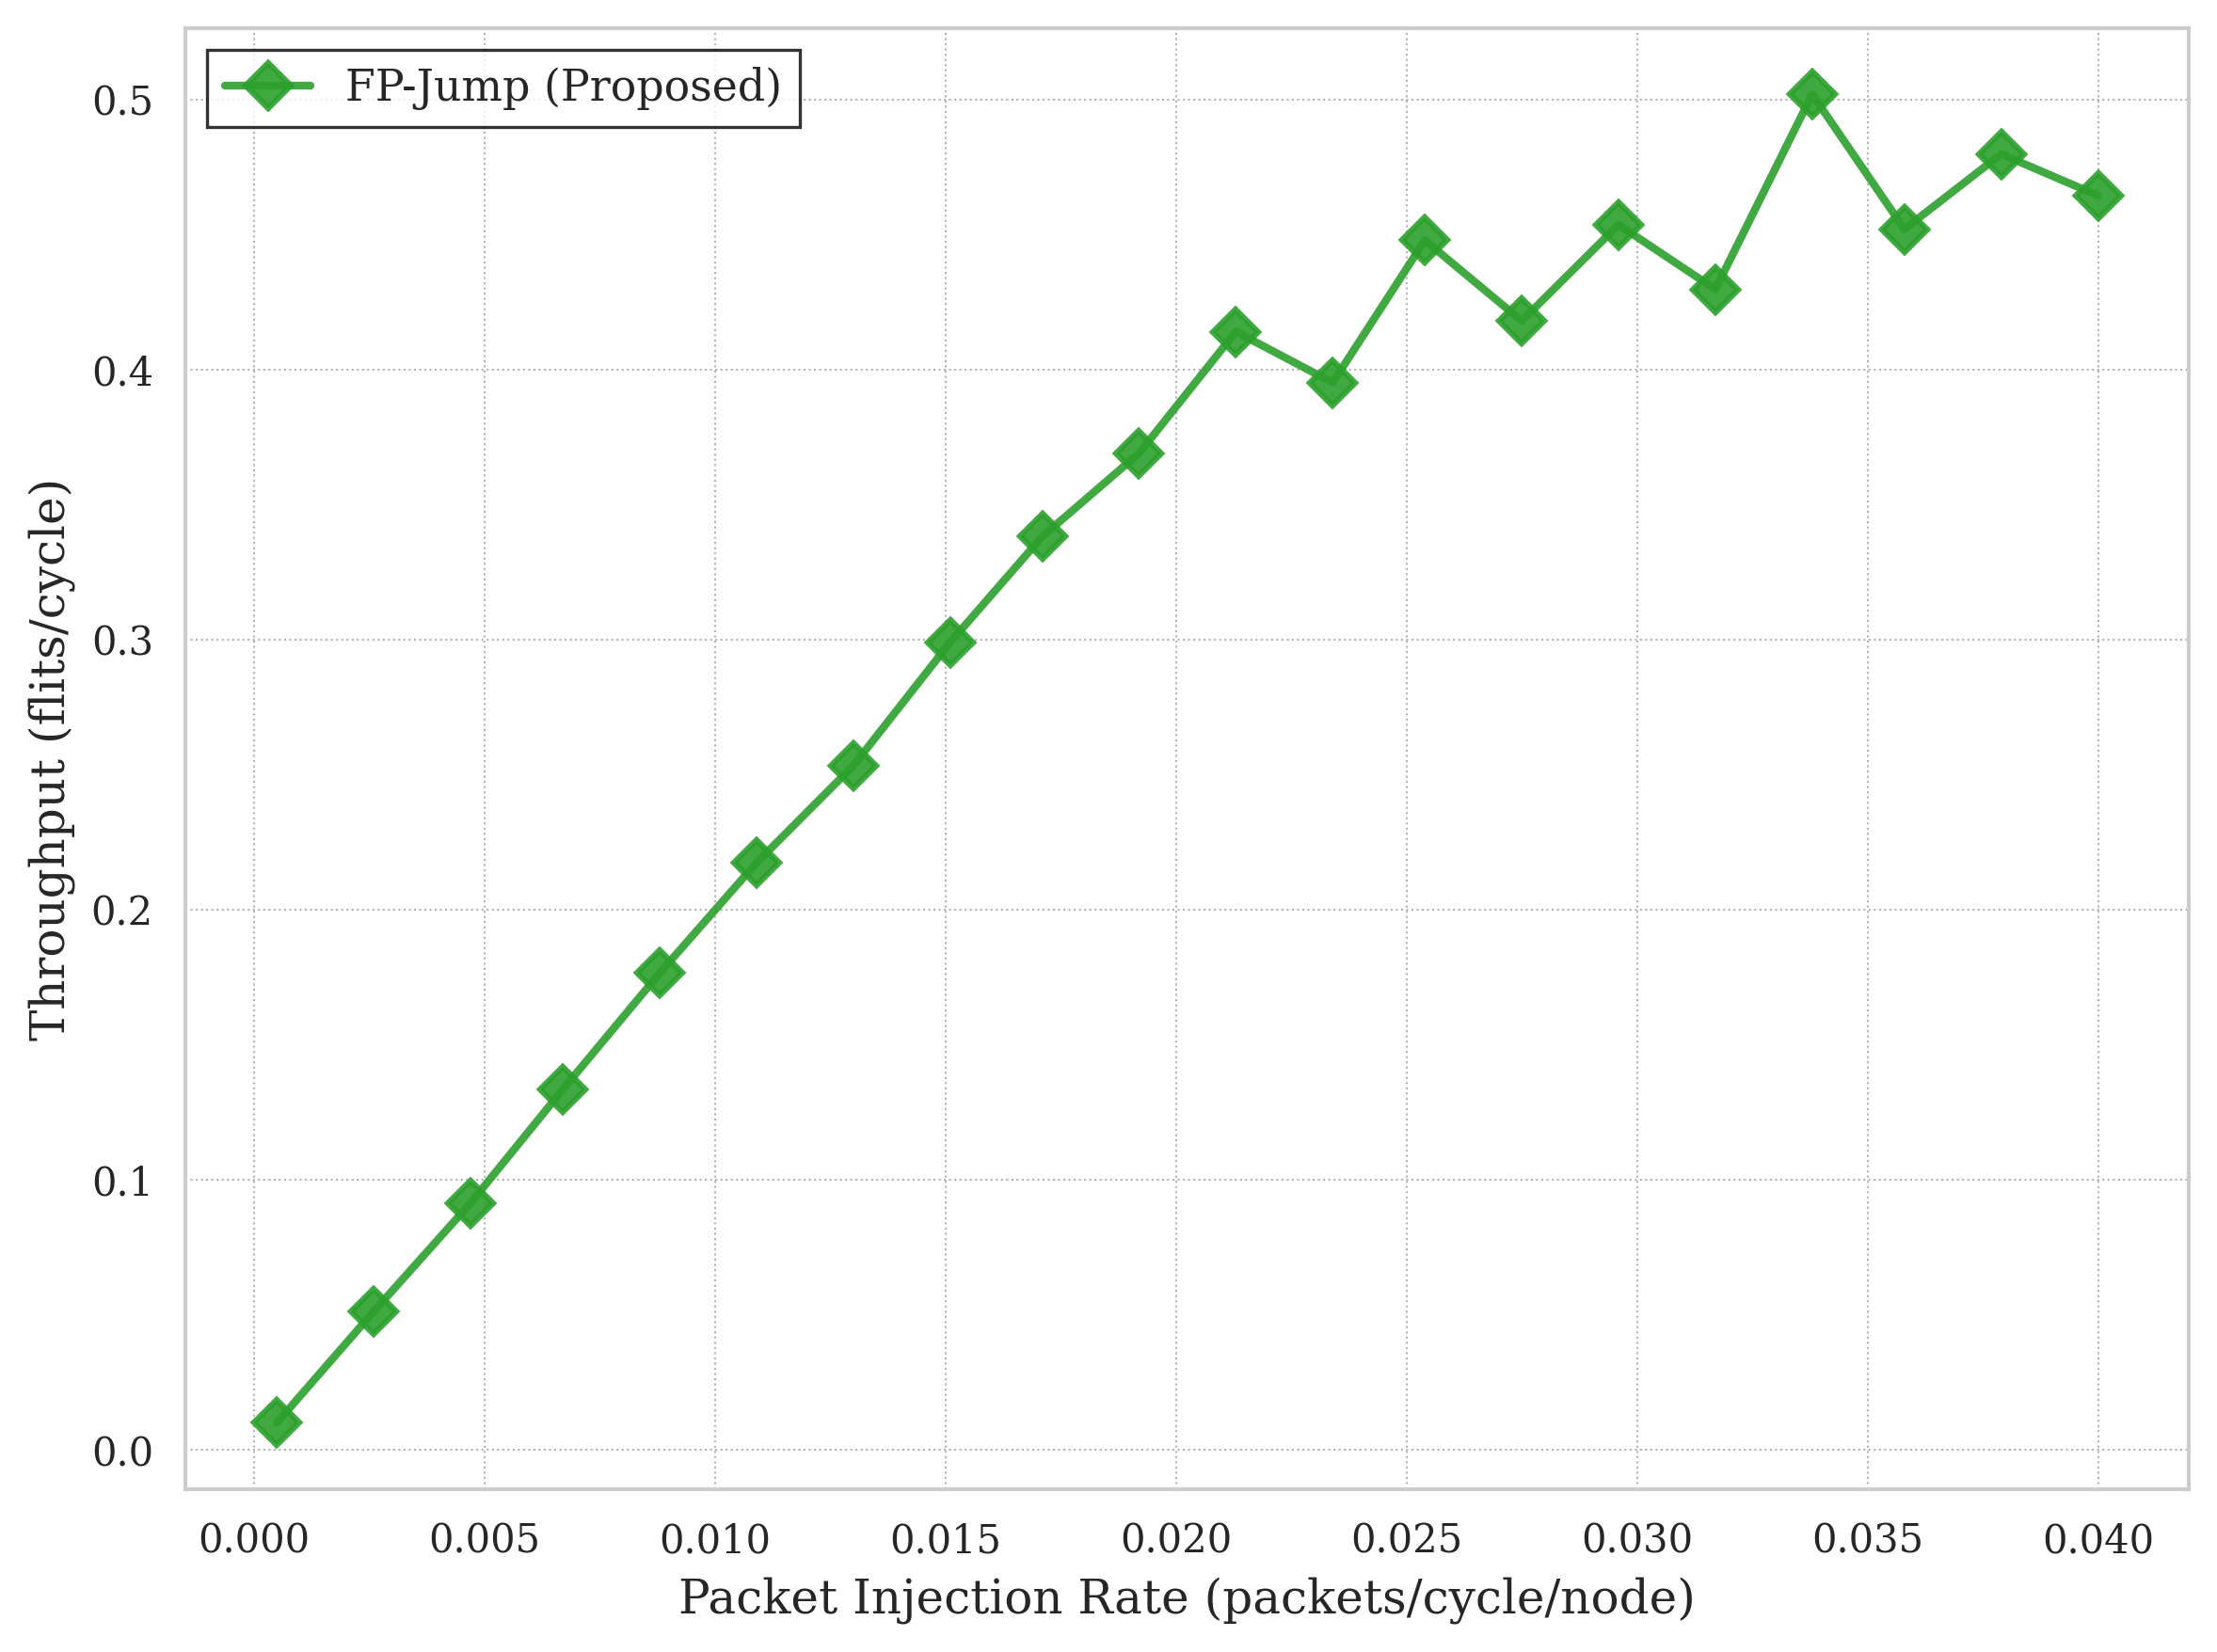

In [8]:
# --- 4. Plotting: PIR Sweep Results ---

if not df_pir.empty:
    # Figure 1: Throughput
    plot_comparisons(df_pir, "pir", "throughput", "Figure 1: Throughput Analysis", "Throughput (flits/cycle)", filename="fig1_throughput.png")

    # Figure 2: Average Latency
    plot_comparisons(df_pir, "pir", "avg_delay", "Figure 2: Average Latency", "Average Latency (cycles)", filename="fig2_latency.png")

    # Figure 7: Upper Bound
    df_rg = df_pir[df_pir["protocol"].isin(["FP-Jump", "FP-Jump + RG"])]
    if not df_rg.empty:
        plot_comparisons(df_rg, "pir", "throughput", "Figure 7: Impact of Readiness Gating", "Throughput (flits/cycle)", filename="fig7_rg.png")
else:
    print("No data available to plot.")

In [11]:
# --- 4A. Simulation: Load Sweep for Wireless Dynamic Energy per Successfully Delivered Packet (Multi-Seed) ---
# Runs a standard lambda sweep in detailed mode and computes:
# 1) Total-system energy per successfully delivered packet
# 2) Wireless dynamic energy (wireless_tx + wireless_dynamic_rx_pwr) per successfully delivered packet

LAMBDA_LIST_STANDARD = [round(x, 4) for x in np.linspace(0.0001, 0.04, 10)]

# Detailed-only power breakdown fields from noxim output
WIRELESS_TX_PATTERN = re.compile(r"([0-9.eE+-]+)\s+%\s+wireless_tx\b")
WIRELESS_RX_PATTERN = re.compile(r"([0-9.eE+-]+)\s+%\s+wireless_dynamic_rx_pwr\b")


def run_noxim_detailed_energy(config_path, pir_val, seed):
    """Run noxim in detailed mode and parse wireless dynamic breakdown fields."""
    cmd = [NOXIM_EXEC, "-config", str(config_path), "-seed", str(seed), "-pir", str(pir_val), "poisson", "-detailed"]
    try:
        proc = subprocess.run(
            cmd,
            cwd=str(NOXIM_BIN_DIR),
            capture_output=True,
            text=True,
            timeout=180,
        )
        if proc.returncode != 0:
            print(f"Error running noxim detailed: {proc.stderr}")
            return {}

        m = parse_noxim_output(proc.stdout)

        tx_match = WIRELESS_TX_PATTERN.search(proc.stdout)
        rx_match = WIRELESS_RX_PATTERN.search(proc.stdout)
        m["wireless_tx"] = float(tx_match.group(1)) if tx_match else float("nan")
        m["wireless_dynamic_rx_pwr"] = float(rx_match.group(1)) if rx_match else float("nan")
        return m
    except Exception as e:
        print(f"Exception in detailed run: {e}")
        return {}


results_lambda_energy = []
print(f"Running detailed load sweep for wireless dynamic energy per successfully delivered packet ({NUM_SEEDS} seeds) with parallel execution...")

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    for protocol_name, config_path in PROTOCOLS.items():
        print(f"  Protocol: {protocol_name}")

        for lam in LAMBDA_LIST_STANDARD:
            futures = [executor.submit(run_noxim_detailed_energy, config_path, lam, s) for s in SEEDS]
            runs = []

            for f in futures:
                m = f.result()
                total_energy = m.get("total_energy", float("nan"))
                delivered_packets = m.get("received_packets", float("nan"))
                wireless_tx = m.get("wireless_tx", float("nan"))
                wireless_rx = m.get("wireless_dynamic_rx_pwr", float("nan"))

                if pd.notna(total_energy) and pd.notna(delivered_packets) and delivered_packets > 0:
                    e_per_pkt_j = total_energy / delivered_packets
                    m["energy_per_successfully_delivered_packet_J"] = e_per_pkt_j
                    m["energy_per_successfully_delivered_packet_pJ"] = e_per_pkt_j * 1.0e12
                else:
                    m["energy_per_successfully_delivered_packet_J"] = float("nan")
                    m["energy_per_successfully_delivered_packet_pJ"] = float("nan")

                if (
                    pd.notna(wireless_tx)
                    and pd.notna(wireless_rx)
                    and pd.notna(delivered_packets)
                    and delivered_packets > 0
                ):
                    wireless_dynamic_j = wireless_tx + wireless_rx
                    m["wireless_dynamic_energy_J"] = wireless_dynamic_j
                    m["wireless_dynamic_energy_per_successfully_delivered_packet_J"] = wireless_dynamic_j / delivered_packets
                    m["wireless_dynamic_energy_per_successfully_delivered_packet_pJ"] = (
                        wireless_dynamic_j / delivered_packets
                    ) * 1.0e12
                else:
                    m["wireless_dynamic_energy_J"] = float("nan")
                    m["wireless_dynamic_energy_per_successfully_delivered_packet_J"] = float("nan")
                    m["wireless_dynamic_energy_per_successfully_delivered_packet_pJ"] = float("nan")

                runs.append(m)

            agg = aggregate_runs(runs)
            results_lambda_energy.append(
                {
                    "protocol": protocol_name,
                    "lambda": lam,
                    "load_pkts_per_cycle_per_core": lam,
                    "load_pkts_per_cycle_per_chip": lam * 64.0,
                    "total_energy_J": agg.get("total_energy"),
                    "total_received_packets": agg.get("received_packets"),
                    "simulation_cycles": agg.get("simulation_cycles"),
                    "energy_per_successfully_delivered_packet_J": agg.get("energy_per_successfully_delivered_packet_J"),
                    "energy_per_successfully_delivered_packet_pJ": agg.get("energy_per_successfully_delivered_packet_pJ"),
                    "wireless_tx_J": agg.get("wireless_tx"),
                    "wireless_dynamic_rx_pwr_J": agg.get("wireless_dynamic_rx_pwr"),
                    "wireless_dynamic_energy_per_successfully_delivered_packet_J": agg.get(
                        "wireless_dynamic_energy_per_successfully_delivered_packet_J"
                    ),
                    "wireless_dynamic_energy_per_successfully_delivered_packet_pJ": agg.get(
                        "wireless_dynamic_energy_per_successfully_delivered_packet_pJ"
                    ),
                }
            )


df_lambda_energy = pd.DataFrame(results_lambda_energy)

# Keep both outputs: legacy filename + explicit wireless-dynamic filename
df_lambda_energy.to_csv(PLOTS_DIR / "load_energy_per_successful_packet_profile.csv", index=False)
df_lambda_energy.to_csv(PLOTS_DIR / "load_energy_per_successful_packet_profile_wireless_dynamic.csv", index=False)

print("Detailed load sweep complete.")
display(df_lambda_energy.head())

Running load sweep for energy per successfully delivered packet (10 seeds) with parallel execution...
  Protocol: Token Passing
  Protocol: Fuzzy Token
  Protocol: FP-Jump
Load sweep for energy per successfully delivered packet complete.


,protocol,lambda,load_pkts_per_cycle_per_core,load_pkts_per_cycle_per_chip,total_energy_J,total_received_packets,simulation_cycles,energy_per_successfully_delivered_packet_J,energy_per_successfully_delivered_packet_pJ
0,Token Passing,0.0001,0.0001,0.0064,0.000178,7.157196,21000.0,2.490046e-05,2.490046e+07
1,Token Passing,0.0045,0.0045,0.2880,0.000182,335.439415,21000.0,5.418764e-07,5.418764e+05
2,Token Passing,0.0090,0.0090,0.5760,0.000185,673.165379,21000.0,2.753965e-07,2.753965e+05
3,Token Passing,0.0134,0.0134,0.8576,0.000189,971.991221,21000.0,1.940357e-07,1.940357e+05
4,Token Passing,0.0178,0.0178,1.1392,0.000190,1144.413962,21000.0,1.664299e-07,1.664299e+05


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: /Users/nishkarsh/Programming/noxim/results/paper_results/plots/fig_energy_per_successful_packet_vs_load.png
Saved: /Users/nishkarsh/Programming/noxim/results/paper_results/plots/fig_energy_per_successful_packet_vs_load.eps


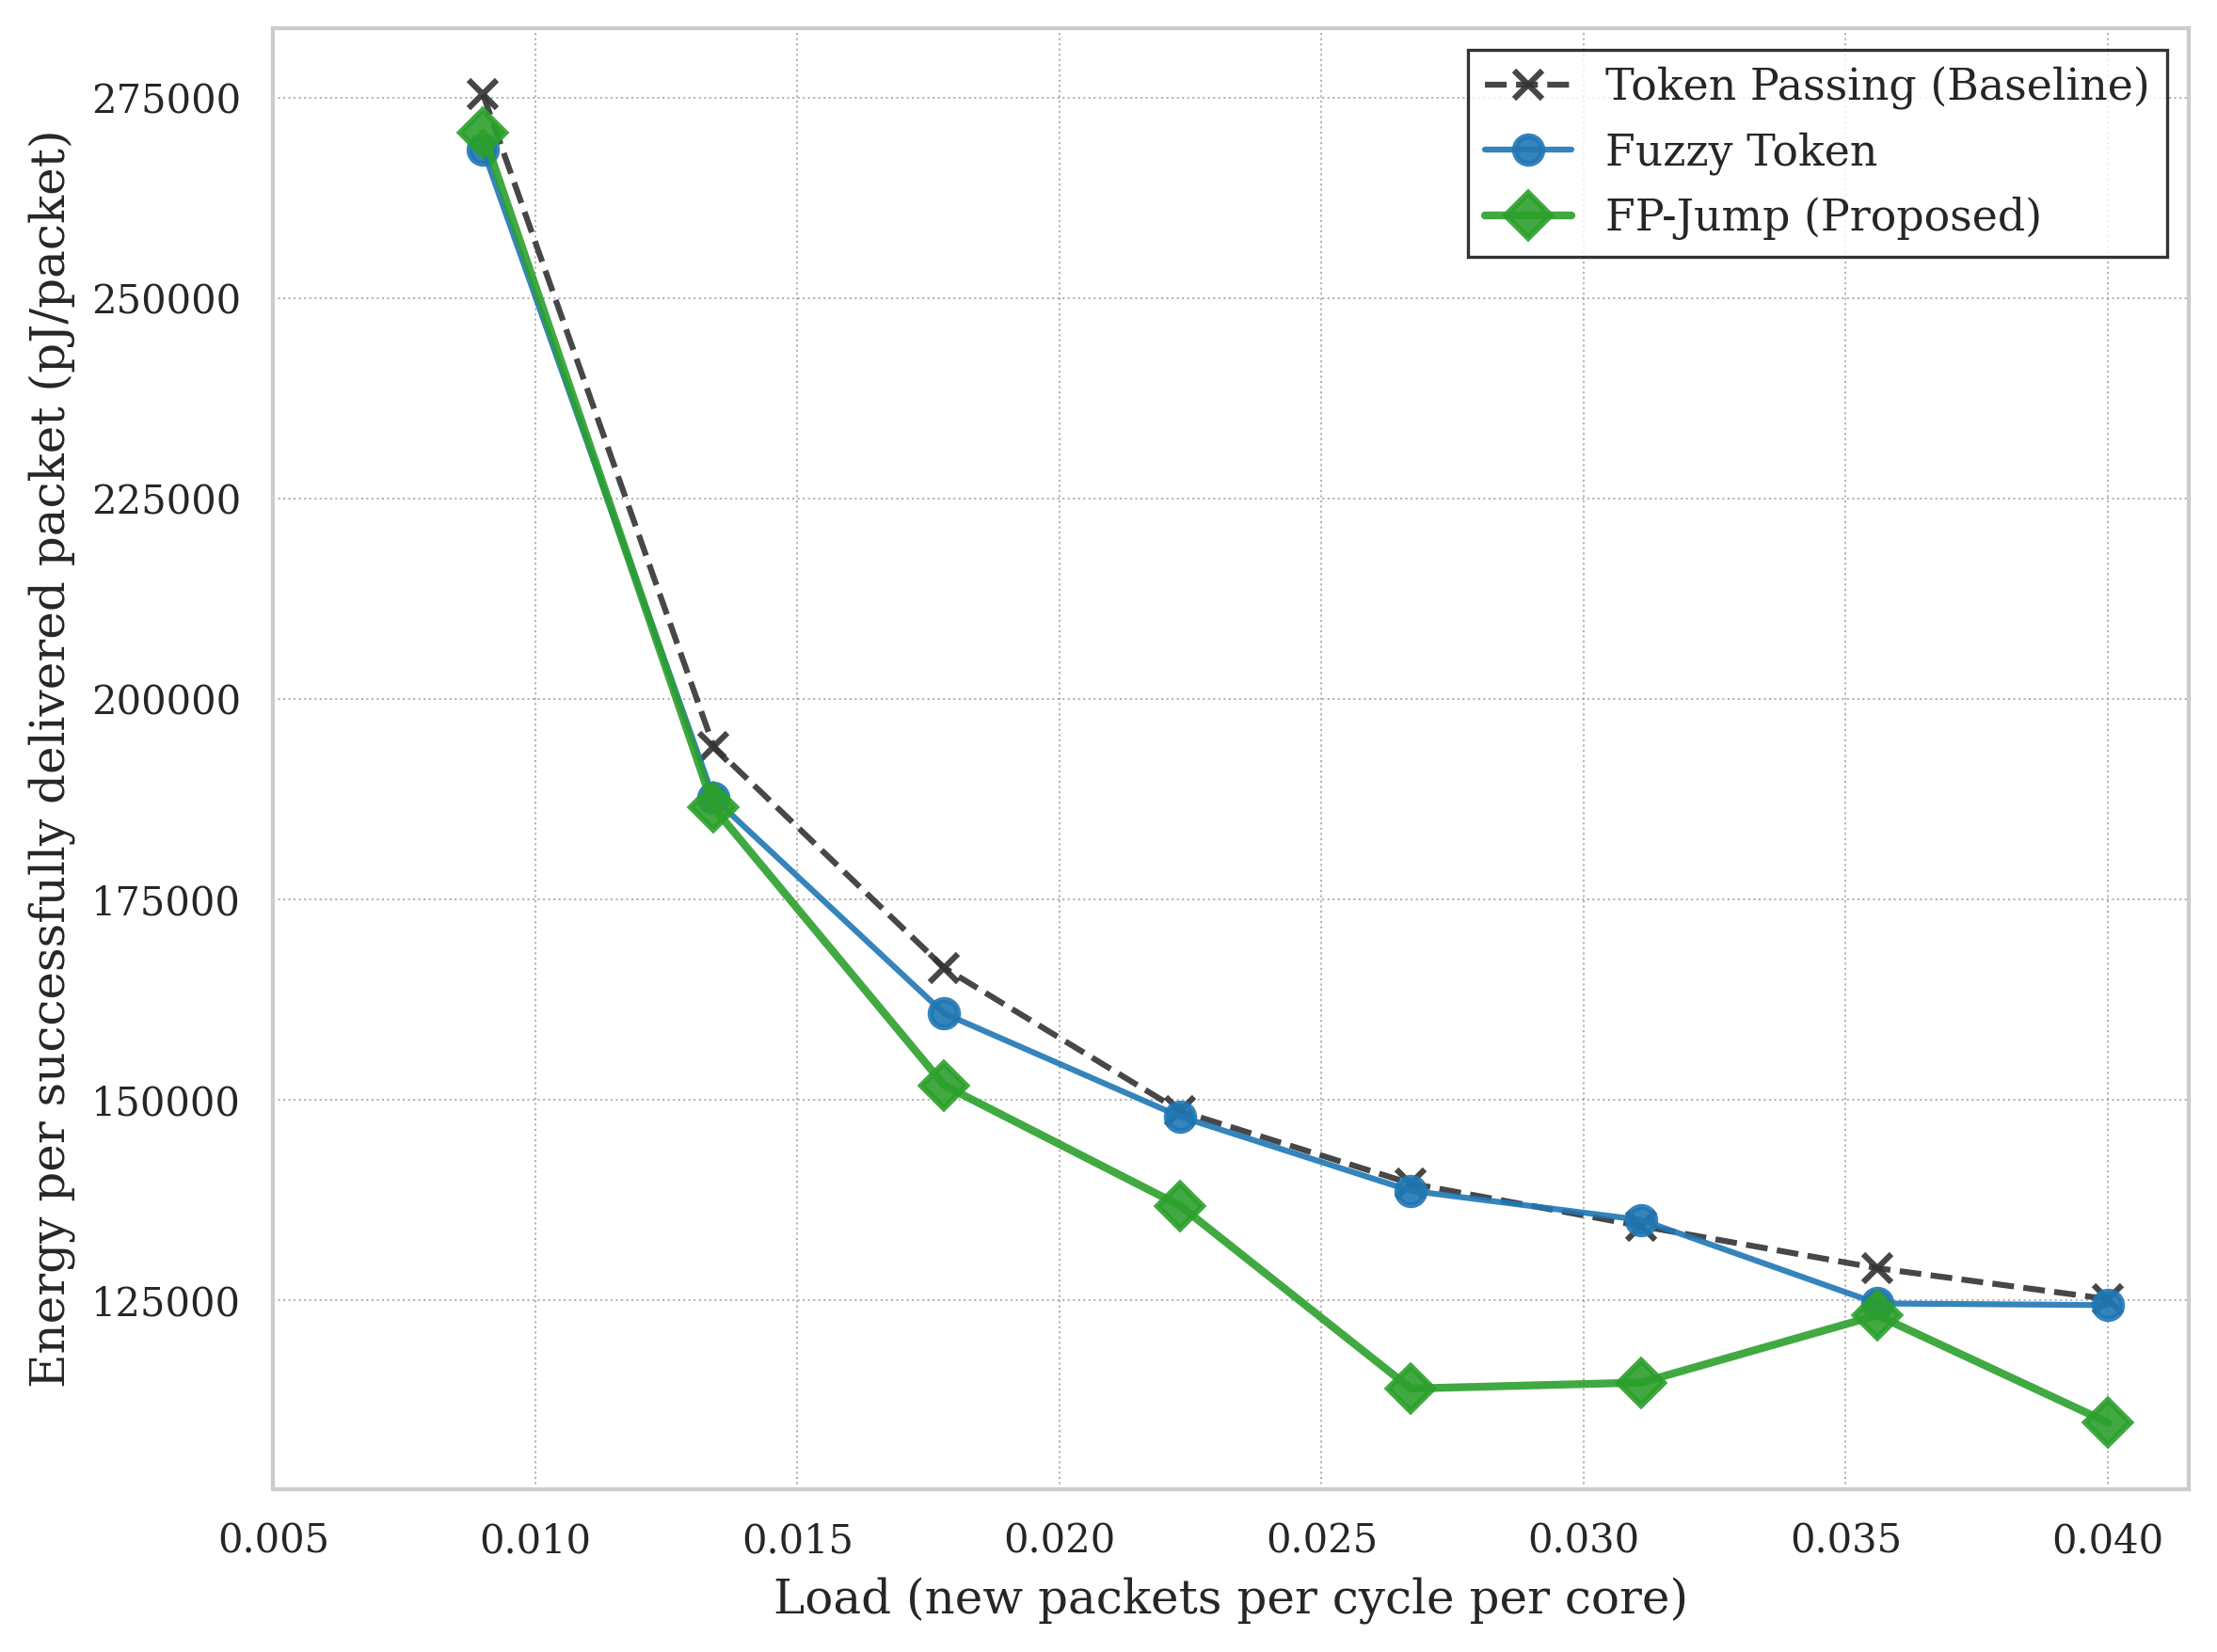

In [12]:
# --- 4B. Plotting: Wireless Dynamic Energy per Successfully Delivered Packet vs Load ---

required_col = "wireless_dynamic_energy_per_successfully_delivered_packet_pJ"
plot_df = df_lambda_energy[df_lambda_energy["load_pkts_per_cycle_per_core"] >= 0.005].copy()

if plot_df.empty:
    print("No load sweep data available at load >= 0.005 to plot.")
elif required_col not in plot_df.columns:
    print("Missing wireless_dynamic_energy_per_successfully_delivered_packet_pJ. Re-run Cell 5 first.")
else:
    plot_comparisons(
        plot_df,
        x_col="load_pkts_per_cycle_per_core",
        y_col=required_col,
        title="Wireless Dynamic Energy per Successfully Delivered Packet vs Load",
        ylabel="Wireless dynamic energy per successfully delivered packet (pJ/packet)",
        filename="fig_wireless_dynamic_energy_per_successful_packet_vs_load.png",
        xlabel_override="Load (new packets per cycle per core)",
        xlim_left=0.005,
    )

In [ ]:
# --- 4C. Plotting: Wireless Dynamic Energy vs Load and Efficiency (bits/pJ) ---
# η = (total_delivered_packets * 48 bits) / (wireless_tx + wireless_dynamic_rx_pwr)
# Denominator is converted from J to pJ to report bits/pJ.

required_cols = [
    "wireless_tx_J",
    "wireless_dynamic_rx_pwr_J",
    "total_received_packets",
    "load_pkts_per_cycle_per_core",
    "protocol",
]

missing = [c for c in required_cols if c not in df_lambda_energy.columns]
if missing:
    print(f"Missing required columns: {missing}. Re-run Cell 5 first.")
else:
    viz_df = df_lambda_energy.copy()
    viz_df["wireless_dynamic_energy_total_J"] = viz_df["wireless_tx_J"] + viz_df["wireless_dynamic_rx_pwr_J"]
    viz_df["wireless_dynamic_energy_total_pJ"] = viz_df["wireless_dynamic_energy_total_J"] * 1.0e12

    valid = (viz_df["wireless_dynamic_energy_total_J"] > 0) & (viz_df["total_received_packets"] > 0)
    viz_df["wireless_dynamic_efficiency_bits_per_pJ"] = float("nan")
    viz_df.loc[valid, "wireless_dynamic_efficiency_bits_per_pJ"] = (
        (viz_df.loc[valid, "total_received_packets"] * 48.0)
        / (viz_df.loc[valid, "wireless_dynamic_energy_total_J"] * 1.0e12)
    )

    # Save enriched results for reproducibility
    viz_df.to_csv(PLOTS_DIR / "load_energy_profile_wireless_dynamic_efficiency.csv", index=False)

    plot_df = viz_df[viz_df["load_pkts_per_cycle_per_core"] >= 0.005].copy()

    if plot_df.empty:
        print("No load sweep data available at load >= 0.005 to plot.")
    else:
        plot_comparisons(
            plot_df,
            x_col="load_pkts_per_cycle_per_core",
            y_col="wireless_dynamic_energy_total_pJ",
            title="Total Wireless Dynamic Energy vs Load",
            ylabel="Total wireless dynamic energy (pJ)",
            filename="fig_total_wireless_dynamic_energy_vs_load.png",
            xlabel_override="Load (new packets per cycle per core)",
            xlim_left=0.005,
        )

        plot_comparisons(
            plot_df,
            x_col="load_pkts_per_cycle_per_core",
            y_col="wireless_dynamic_efficiency_bits_per_pJ",
            title="Wireless Dynamic Energy Efficiency vs Load",
            ylabel="Wireless dynamic energy efficiency (bits/pJ)",
            filename="fig_wireless_dynamic_efficiency_vs_load.png",
            xlabel_override="Load (new packets per cycle per core)",
            xlim_left=0.005,
        )

        print("Wireless dynamic efficiency summary (mean bits/pJ, load >= 0.005):")
        display(
            plot_df.groupby("protocol")["wireless_dynamic_efficiency_bits_per_pJ"]
            .mean()
            .sort_values(ascending=False)
            .to_frame("mean_bits_per_pJ")
        )

In [9]:
# --- 5. Simulation: Hurst Sweep (Multi-Seed) ---
# Sensitivity to Temporal Burstiness (H)

HURST_LIST = [round(x, 2) for x in np.linspace(0.5, 0.9, 5)]
FIXED_PIR_HURST = 0.025
# Reuse NUM_SEEDS and SEEDS from previous section

RESULTS_HURST = []
print("Running Hurst Sweep with parallel execution...")

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    for protocol_name, src_config in PROTOCOLS.items():
        if protocol_name == "FP-Jump + RG": continue 
        
        print(f"  Protocol: {protocol_name}")
        
        # Load base config
        with open(src_config, 'r') as f:
            base_cfg = yaml.safe_load(f)
            
        for h in HURST_LIST:
            futures = []
            for s in SEEDS:
                # Create temp config for this seed/param combination
                cfg = base_cfg.copy()
                cfg['traffic_soteriou_sigma'] = 3.0  # Fixed high sigma
                cfg['traffic_soteriou_hurst'] = float(h)
                
                # Unique filename is crucial for parallel access
                unique_name = f"hurst_{protocol_name.replace(' ', '')}_H{h}_S{s}.yaml"
                
                # Submit helper which handles file I/O safely
                futures.append(executor.submit(run_with_temp_config, cfg, unique_name, s, FIXED_PIR_HURST))
                
            runs = [f.result() for f in futures]
            
            agg = aggregate_runs(runs)
            entry = {
                "protocol": protocol_name,
                "hurst": h,
                "avg_delay": agg.get("global_average_delay"),
                "throughput": agg.get("network_throughput"), 
                "energy_J": agg.get("total_energy"),
                "energy_per_pkt": agg.get("energy_per_pkt"),
                "pkts": agg.get("received_packets")
            }
            RESULTS_HURST.append(entry)
        
df_hurst = pd.DataFrame(RESULTS_HURST)
print("Hurst Sweep Complete.")

Running Hurst Sweep with parallel execution...
  Protocol: Token Passing
  Protocol: Fuzzy Token
  Protocol: FP-Jump
Hurst Sweep Complete.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: /Users/nishkarsh/Programming/noxim/results/paper_results/plots/fig4_hurst.png
Saved: /Users/nishkarsh/Programming/noxim/results/paper_results/plots/fig4_hurst.eps


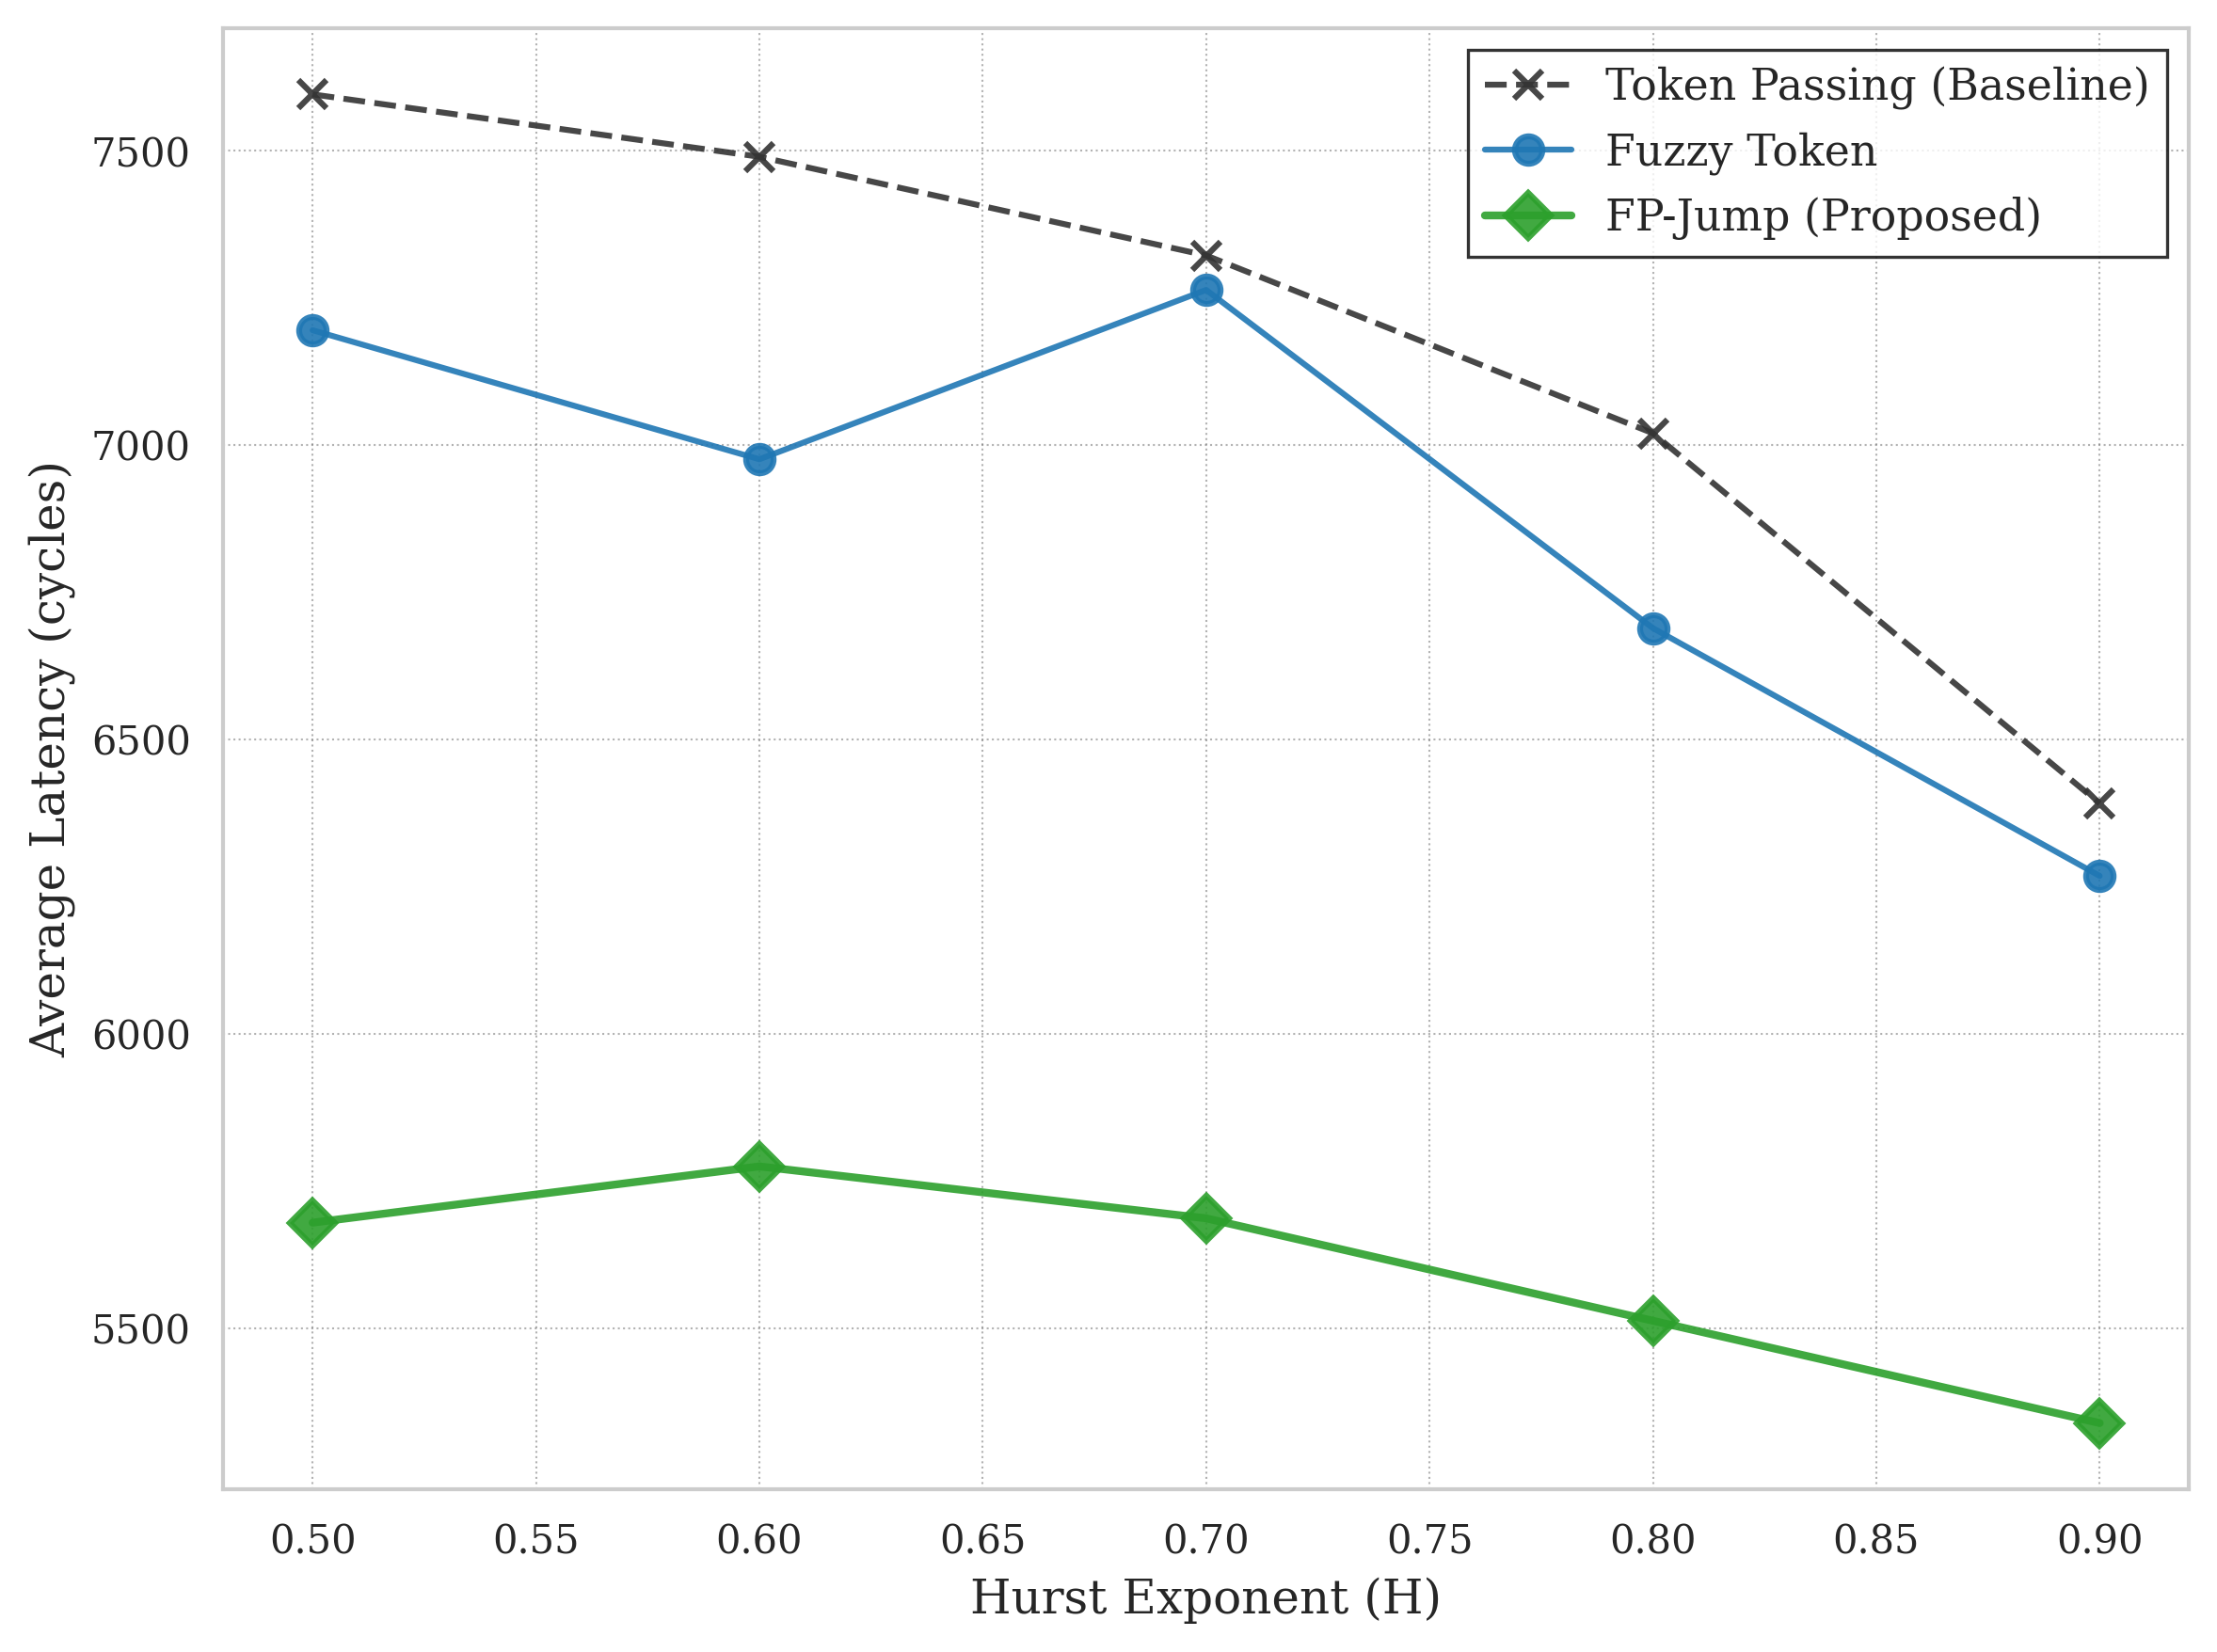

In [10]:
# --- 6. Plotting: Hurst Sweep ---
if not df_hurst.empty:
    plot_comparisons(df_hurst, "hurst", "avg_delay", "Figure 4: Sensitivity to Hurst (H)", "Average Latency (cycles)", filename="fig4_hurst.png")
else:
    print("No Hurst data.")

In [11]:
# --- 7. Simulation: Sigma Sweep (Multi-Seed) ---
# Sensitivity to Spatial Hotspotness (Sigma)

SIGMA_LIST = [0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 2.5, 3.0]
FIXED_PIR_SIGMA = 0.025
RESULTS_SIGMA = []

print("Running Sigma Sweep with parallel execution...")

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    for protocol_name, src_config in PROTOCOLS.items():
        print(f"  Protocol: {protocol_name}")
        with open(src_config, 'r') as f:
            base_cfg = yaml.safe_load(f)
            
        for sigma in SIGMA_LIST:
            futures = []
            for s in SEEDS:
                cfg = base_cfg.copy()
                cfg['traffic_soteriou_hurst'] = 0.5
                cfg['traffic_soteriou_sigma'] = float(sigma)
                
                unique_name = f"sigma_{protocol_name.replace(' ', '')}_S{sigma}_SD{s}.yaml"
                futures.append(executor.submit(run_with_temp_config, cfg, unique_name, s, FIXED_PIR_SIGMA))
                
            runs = [f.result() for f in futures]
                
            agg = aggregate_runs(runs)
            
            entry = {
                "protocol": protocol_name,
                "sigma": sigma,
                "avg_delay": agg.get("global_average_delay"),
                "throughput": agg.get("network_throughput"), 
                "energy_J": agg.get("total_energy"),
                "energy_per_pkt": agg.get("energy_per_pkt"),
                "pkts": agg.get("received_packets")
            }
            RESULTS_SIGMA.append(entry)

df_sigma = pd.DataFrame(RESULTS_SIGMA)
print("Sigma Sweep Complete.")

Running Sigma Sweep with parallel execution...
  Protocol: Token Passing
  Protocol: Fuzzy Token
  Protocol: FP-Jump
Sigma Sweep Complete.


<>:30: SyntaxWarning: invalid escape sequence '\s'
<>:30: SyntaxWarning: invalid escape sequence '\s'
/var/folders/18/8hrwl15d0fx27gywdl96mvjc0000gn/T/ipykernel_2658/2204394673.py:30: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("$\sigma$ (Low = Hotspot, High = Uniform)")
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: /Users/nishkarsh/Programming/noxim/results/paper_results/plots/fig5_sigma.png
Saved: /Users/nishkarsh/Programming/noxim/results/paper_results/plots/fig5_sigma.eps


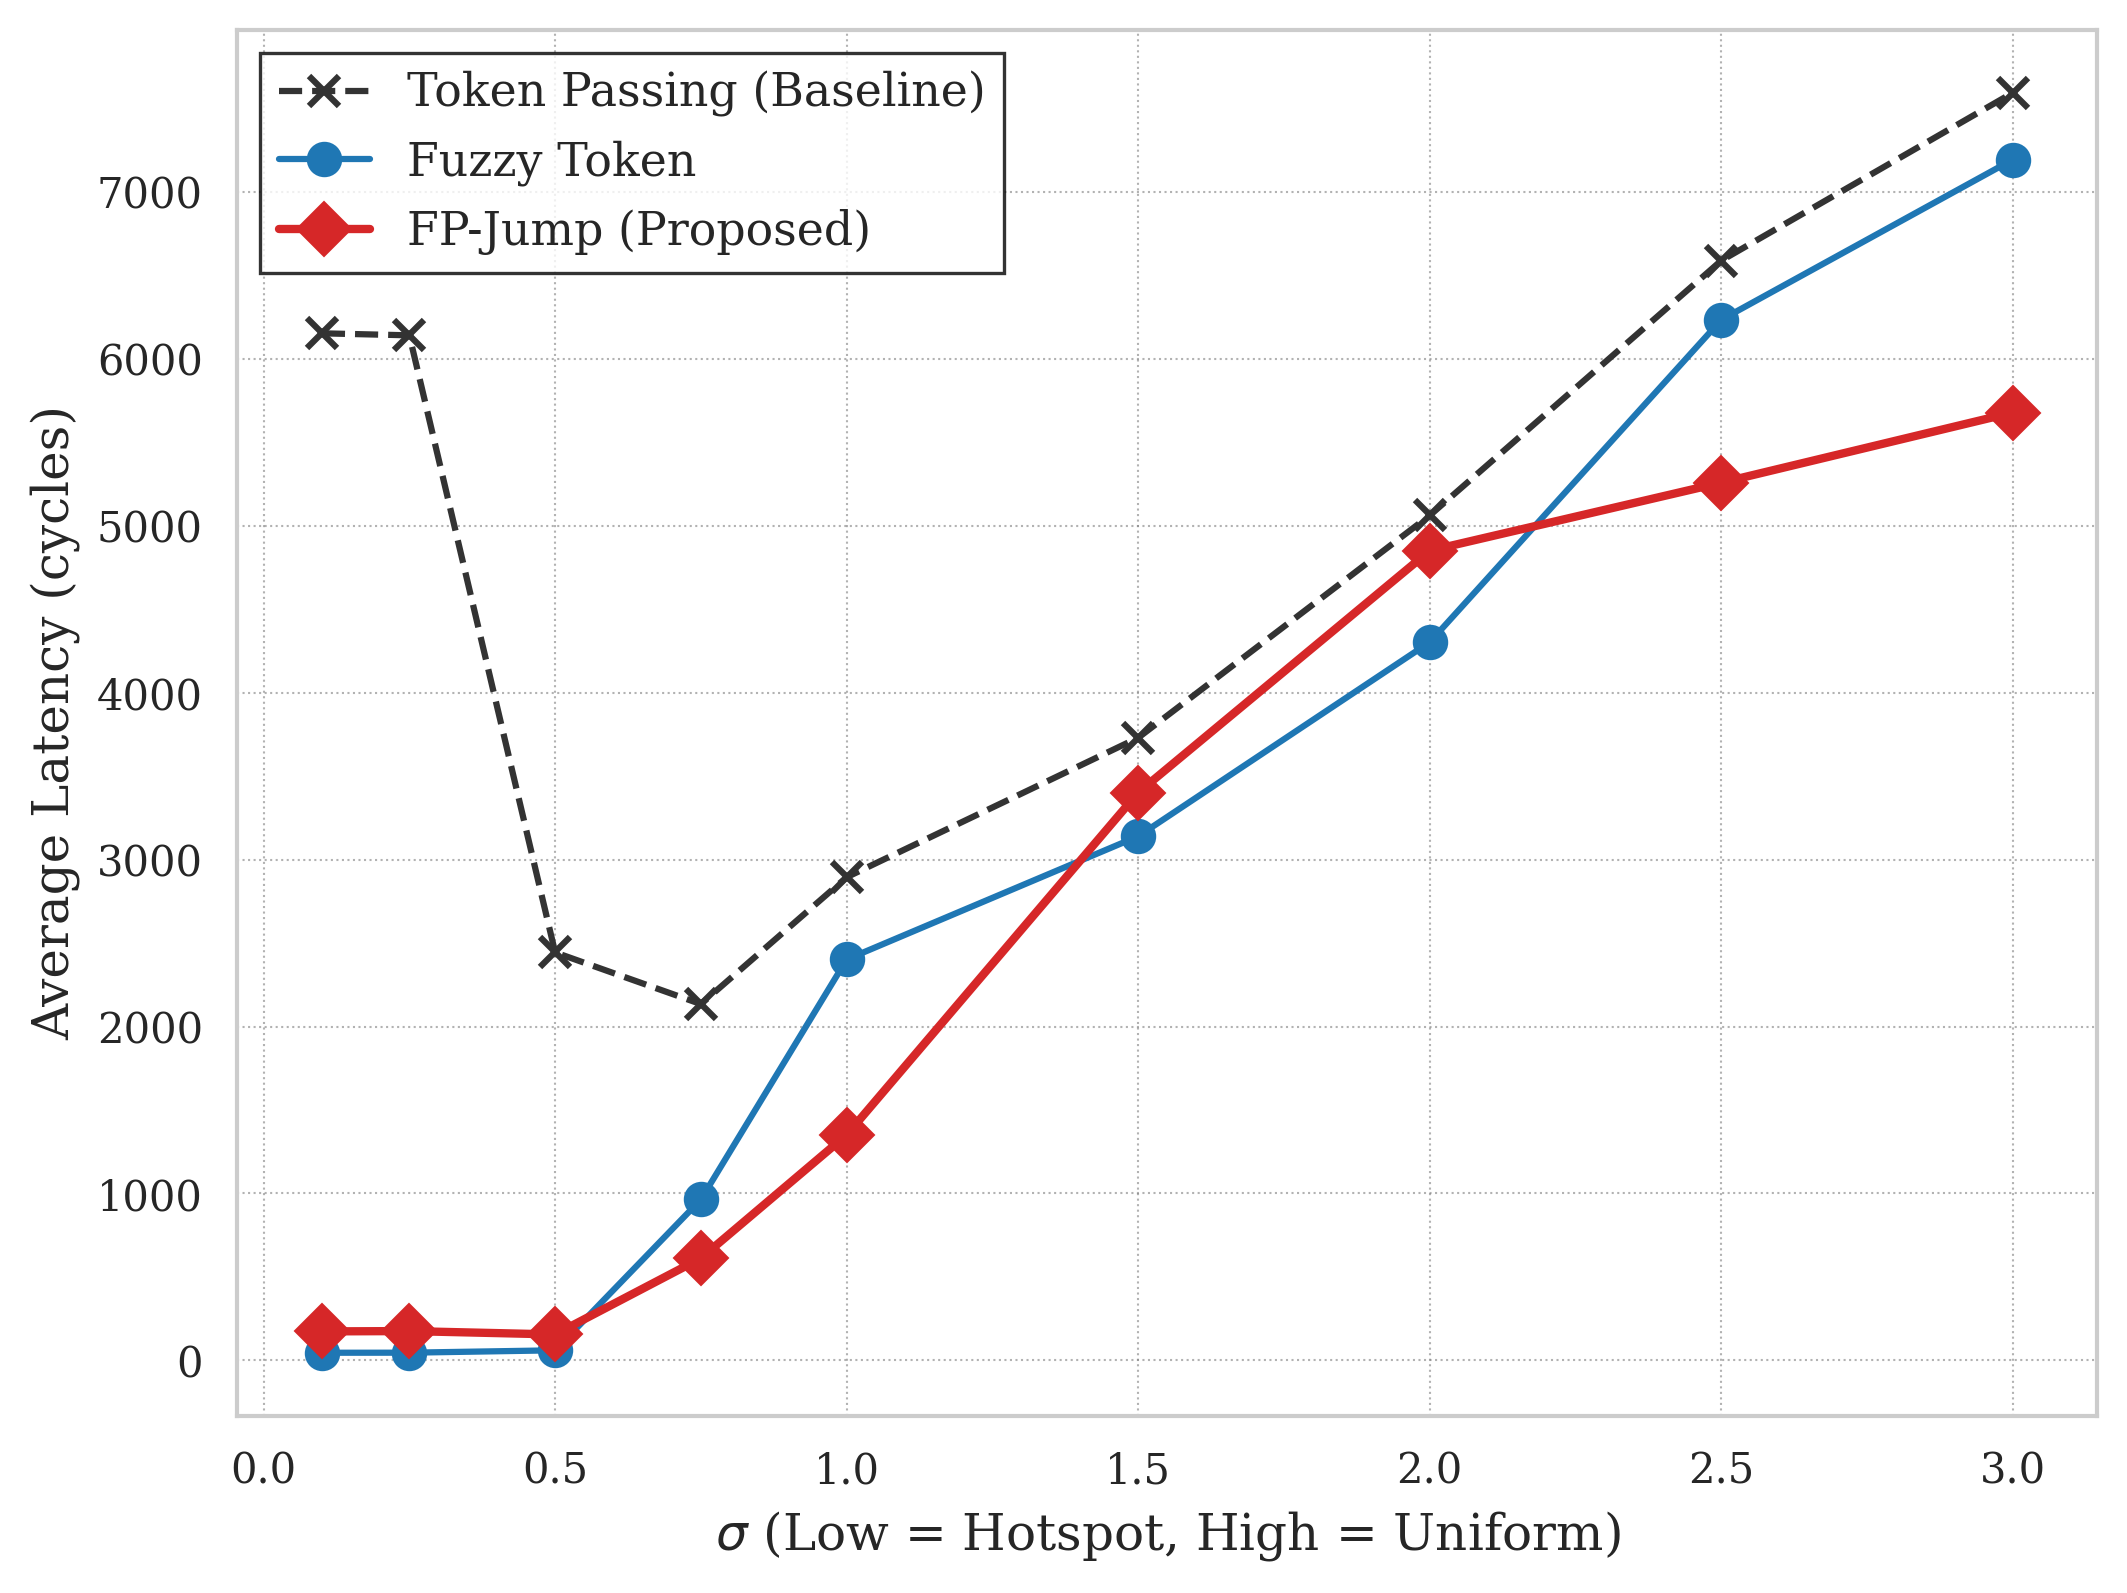

In [12]:
# --- 8. Plotting: Sigma Sweep ---
if not df_sigma.empty:
    # Use generic plotter but custom x-sort since sigma is non-monotonic? No, sigma is float.
    # We might want to invert axis or just label carefully.
    
    plt.figure(figsize=(8, 6))
    
    # Re-use style map logic manually since we want specific Sigma handling
    style_map = {
        "Token Passing":      {"marker": "x", "color": "#333333", "linestyle": "--", "label": "Token Passing (Baseline)"},
        "Fuzzy Token":        {"marker": "o", "color": "#1f77b4", "linestyle": "-",  "label": "Fuzzy Token"},
        "FP-Jump":            {"marker": "D", "color": "#d62728", "linestyle": "-",  "label": "FP-Jump (Proposed)"},
        # "FP-Jump + RG":       {"marker": "^", "color": "#2ca02c", "linestyle": "-.", "label": "FP-Jump + RG (Ideal)"}
    }

    for proto in df_sigma["protocol"].unique():
        if proto not in style_map: continue
        subset = df_sigma[df_sigma["protocol"] == proto].sort_values("sigma")
        s = style_map[proto]
        plt.plot(subset["sigma"], subset["avg_delay"], 
                 label=s["label"], 
                 marker=s["marker"], 
                 color=s["color"],
                 linestyle=s["linestyle"],
                 linewidth=2 if proto == "FP-Jump" else 1.5, 
                 markersize=8 if proto == "FP-Jump" else 7,
                 markeredgewidth=1.5)

    # plt.title("Figure 5: Sensitivity to Spatial Distribution (Sigma)", pad=15)
    plt.xlabel("$\sigma$ (Low = Hotspot, High = Uniform)")
    plt.ylabel("Average Latency (cycles)")
    plt.legend(frameon=True, fancybox=False, edgecolor='black', loc='best')
    plt.grid(True, which="both", linestyle=':', linewidth=0.5, alpha=0.6, color='gray')
    
    save_figure_png_eps("fig5_sigma.png", dpi=300)
    plt.show()
else:
    print("No Sigma data.")

In [13]:
# --- Section 5: Timeline & Fairness (Viz) ---

# Run one simulation with logging enabled to generate CSV
# Using FP-Jump (fuzzy_swj) as the interesting one
viz_config_src = PROTOCOLS["FP-Jump"]
viz_config_temp = TEMP_CONFIG_DIR / "viz_run.yaml"

with open(viz_config_src, 'r') as f:
    cfg = yaml.safe_load(f)
    
cfg["csv_log_enabled"] = True
cfg["csv_mac_log_filename"] = "viz_log.csv"
cfg["simulation_time"] = 2000 # Short run for viz
cfg["packet_injection_rate"] = 0.02
cfg["traffic_distribution"] = "TRAFFIC_SOTERIOU"

with open(viz_config_temp, 'w') as f:
    yaml.dump(cfg, f)

print("Running Viz Simulation...")
run_noxim(viz_config_temp, seed=SEED)

# Load CSV
csv_path = NOXIM_BIN_DIR / "viz_log.csv"
if csv_path.exists():
    df_log = pd.read_csv(csv_path, dtype={'ready_nodes': str, 'fa_nodes': str})
    
    # 1. Timeline Plot
    sim_limit = 500
    df_slice = df_log[:sim_limit]
    
    plt.figure(figsize=(10, 5)) # Wider, shorter for timeline
    
    # Ready matrix background
    if not df_slice.empty and "ready_nodes" in df_slice.columns:
        num_nodes = 64
        ready_matrix = np.zeros((num_nodes, len(df_slice)))
        for t, ready_str in enumerate(df_slice["ready_nodes"]):
             if isinstance(ready_str, str) and len(ready_str) == num_nodes:
                  for nid, char in enumerate(ready_str):
                      if char == '1': ready_matrix[nid, t] = 1
                      
        cmap = ListedColormap([(1,1,1,0), (0.2, 0.8, 0.2, 0.3)]) # Transparent, Green tint
        plt.imshow(ready_matrix, aspect='auto', origin='lower', 
                   extent=[0, sim_limit, -0.5, 63.5], cmap=cmap, interpolation='nearest')
                   
    plt.plot(df_slice["step_id"], df_slice["current_token_holder"], color='navy', linestyle='-', linewidth=0.8, markersize=2, label="Token Holder")
    plt.title("Timeline: Token Trajectory vs Station Readiness", pad=15)
    plt.xlabel("Simulation Cycle")
    plt.ylabel("Node ID")
    plt.legend(loc='upper right', frameon=True)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save_figure_png_eps("viz_timeline.png", dpi=300)
    plt.show()

    # 2. Supply vs Demand
    # Count total ready vs total served (token held)
    ready_arr = np.zeros(64)
    served_arr = np.zeros(64)
    
    for idx, row in df_log.iterrows():
        # Ready
        s = row['ready_nodes']
        if isinstance(s, str) and len(s)==64:
             for i, c in enumerate(s):
                 if c=='1': ready_arr[i] += 1
        # Served
        h = int(row['current_token_holder'])
        if 0 <= h < 64:
            served_arr[h] += 1
            
    plt.figure(figsize=(7, 6))
    sc = plt.scatter(ready_arr, served_arr, c=range(64), cmap='viridis', alpha=0.8, s=60, edgecolor='k', linewidth=0.5)
    plt.colorbar(sc, label="Node ID")
    plt.xlabel("Demand (Cycles Ready)")
    plt.ylabel("Supply (Cycles Holding Token)")
    
    # y=x line
    max_val = max(max(ready_arr), max(served_arr))
    plt.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label="Ideal Fairness")
    
    plt.title("Supply vs Demand Fairness", pad=15)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    save_figure_png_eps("viz_fairness.png", dpi=300)
    plt.show()

else:
    print("CSV Log not found. Simulation might have failed.")

Running Viz Simulation...


NameError: name 'SEED' is not defined